# 5.1 Stage 1: 2D Cost-Level x Transition Classification

**Goal:** Predict each patient's 2D risk class (Y1 cost level x transition direction) from Year 1 features, and generate a continuous `LATENT_RISK_SCORE` for downstream modeling.

**Why 2D?** A 1D transition system groups patients with vastly different cost levels together (e.g., Low->Low at $100 and Extreme->Extreme at $50K are both "Stable"). The 2D system crosses 3 Y1 levels with transition direction, ensuring each class has similar starting cost AND trajectory.

**10-Class Target (`RISK_TIER`):**
- 0 = Low_Improve (Y1 low, cost dropped)
- 1 = Low_Stable (Y1 low, same bin)
- 2 = Low_MildRise (Y1 low, +1 bin)
- 3 = Low_Jumper (Y1 low, +2 or more bins)
- 4 = Mid_Improve (Y1 mid, cost dropped)
- 5 = Mid_Stable (Y1 mid, same bin)
- 6 = Mid_Escalate (Y1 mid, cost increased)
- 7 = High_Improve (Y1 high, cost dropped)
- 8 = High_Stable (Y1 high, same bin)
- 9 = High_Escalate (Y1 high, cost increased)

**Features used:** Demographics (6), Health Status (2), Chronic Conditions (4), Utilization (4), Engineered (3), Medication (9), Clusters (2), Y1 Cost (1).

**Key implication:** Y1 cost is still an important predictor, but transition direction is not determined by cost alone. Clinical/utilization context is needed to separate Improve/Stable/Escalate outcomes within each Y1 level.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import json
from datetime import datetime

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, GroupKFold
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, accuracy_score, brier_score_loss, precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

# Notebook display
from IPython.display import display

# Boosting Models
from xgboost import XGBClassifier

# LightGBM is optional - install with: pip install lightgbm
try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
    print("LightGBM loaded successfully.")
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("Note: LightGBM not installed. Using sklearn GradientBoosting as alternative.")
    print("To install: pip install lightgbm")

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
np.random.seed(42)

# Explicit run version marker (shown at top of Run All output)
STAGE1_NOTEBOOK_VERSION = 'stage1_decisionlayer_v2026_03_17_r1'

# Resolve repo root robustly (works when cwd is repo root or notebooks/)
CWD = Path.cwd()
if (CWD / 'data' / 'processed_v2').exists():
    REPO_ROOT = CWD
elif (CWD.parent / 'data' / 'processed_v2').exists():
    REPO_ROOT = CWD.parent
else:
    REPO_ROOT = CWD

DATA_PATH = REPO_ROOT / 'data' / 'processed_v2' / 'model_ready_v2.parquet'
OUTPUT_STAGE1_PATH = REPO_ROOT / 'data' / 'processed_v2' / 'model_ready_stage1.parquet'
REPORT_DIR = REPO_ROOT / 'reports'
CANONICAL_NB_PATH = REPO_ROOT / 'notebooks' / '5.1_modeling_stage1.ipynb'
(REPORT_DIR / 'figures').mkdir(parents=True, exist_ok=True)
(REPORT_DIR / 'tables').mkdir(parents=True, exist_ok=True)

print("\nSetup complete.")
print(f"Stage1 notebook version: {STAGE1_NOTEBOOK_VERSION}")
print(f"Canonical notebook path: {CANONICAL_NB_PATH}")
print("Important: run this canonical file (not *.bak backups).")
print(f"Repo root: {REPO_ROOT}")
print(f"Input data: {DATA_PATH}")
print(f"Stage 1 output: {OUTPUT_STAGE1_PATH}")

Note: LightGBM not installed. Using sklearn GradientBoosting as alternative.
To install: pip install lightgbm

Setup complete.
Stage1 notebook version: stage1_decisionlayer_v2026_03_17_r1
Canonical notebook path: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/notebooks/5.1_modeling_stage1.ipynb
Important: run this canonical file (not *.bak backups).
Repo root: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo
Input data: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/data/processed_v2/model_ready_v2.parquet
Stage 1 output: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/data/processed_v2/model_ready_stage1.parquet


## 1. Load Processed Data

In [2]:
# Load data from preprocessing notebook
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
print(f"\nColumns: {list(df.columns)}")

CLASS_NAMES = {
    0: 'Low_Improve',   1: 'Low_Stable',    2: 'Low_MildRise',  3: 'Low_Jumper',
    4: 'Mid_Improve',   5: 'Mid_Stable',    6: 'Mid_Escalate',
    7: 'High_Improve',  8: 'High_Stable',   9: 'High_Escalate',
}

print(f"\n{'='*60}")
print("TARGET DISTRIBUTION (RISK_TIER — 2D: Y1 Level × Direction)")
print('='*60)
tier_counts = df['RISK_TIER'].value_counts().sort_index()
tier_pct = (tier_counts / len(df) * 100).round(1)
for tier, count in tier_counts.items():
    label = CLASS_NAMES.get(tier, f'Unknown_{tier}')
    print(f"  {tier:2d} ({label:16s}): {count:>6,} ({tier_pct[tier]}%)")

print(f"\n2D classes: Y1 cost level (Low/Mid/High) × transition direction.")

Loaded 60,602 rows, 43 columns



Columns: ['DUPERSID', 'PANEL', 'START_YEAR', 'AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG', 'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 'HAS_RESPIRATORY_RX', 'HAS_GI_RX', 'RATIO_ER_OFFICE', 'COST_Y1_ADJ', 'COST_Y2_ADJ', 'LOG_COST_Y2', 'Y1_BIN', 'Y2_BIN', 'DELTA_BIN', 'Y1_LEVEL', 'RISK_TIER', 'IS_JUMPER', 'IS_STABLE_LOW', 'CARE_CLUSTER', 'DBSCAN_CLUSTER']

TARGET DISTRIBUTION (RISK_TIER — 2D: Y1 Level × Direction)
   0 (Low_Improve     ):  4,089 (6.7%)
   1 (Low_Stable      ): 15,438 (25.5%)
   2 (Low_MildRise    ):  7,060 (11.6%)
   3 (Low_Jumper      ):  3,534 (5.8%)
   4 (Mid_Improve     ):  5,268 (8.7%)
   5 (Mid_Stable      ):  6,220 (10.3%)
   6 (Mid_Escalate    ):  4,077 (6.7%)
   7 (High_Im

## 2. Feature Selection & Preparation

We use **Year 1 features only** to predict Year 2 outcomes (no data leakage).

### Feature Groups
| Group | Features | Rationale |
|-------|----------|----------|
| Demographics | AGE, SEX, RACE, MARRY, POVCAT, INSCOV | Basic patient characteristics & SES |
| Health Status | MNHLTH_RD1, RTHLTH_RD1 | Self-reported health & trajectory |
| Chronic Conditions | DIAB, HIBP, CHOL flags, CHRONIC_COUNT | Established disease burden |
| Utilization | ER, IP, OB, RX visits | Care-seeking behavior |
| Condition Complexity | CNT_CONDITIONS, ILL_DEFINED | Medical complexity signals |
| **Medication (NEW)** | **CNT_UNIQUE_DRUGS, POLYPHARMACY, Drug Class Flags** | **Rx patterns = reliable disease markers** |
| Clusters | CARE_CLUSTER, DBSCAN_CLUSTER | Patient phenotype groupings |

### Why Medication Features Matter
- **Polypharmacy (≥5 drugs)**: Strong predictor of hospitalizations and adverse events
- **Drug Class Flags**: More reliable than self-reported conditions (reflects active treatment)
- **CNS/Pain Rx**: May indicate mental health burden or chronic pain (high-cost drivers)
- **Cardiovascular Rx**: Captures hypertension/heart disease being actively managed

In [3]:
# Define feature sets by category
DEMOGRAPHIC_FEATS = ['AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1']
HEALTH_FEATS = ['MNHLTH_RD1', 'RTHLTH_RD1']
CHRONIC_FEATS = ['DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT']
UTILIZATION_FEATS = ['UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1']
ENGINEERED_FEATS = ['CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'RATIO_ER_OFFICE']

# Medication Features (NEW - clinically meaningful drug patterns)
MEDICATION_FEATS = [
    'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG',
    'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX',
    'HAS_RESPIRATORY_RX', 'HAS_GI_RX'
]

CLUSTER_FEATS = ['CARE_CLUSTER', 'DBSCAN_CLUSTER']
COST_FEATS = ['COST_Y1_ADJ']  # Year 1 cost is allowed (not leakage)

# Combine all features
ALL_FEATURES = (
    DEMOGRAPHIC_FEATS + HEALTH_FEATS + CHRONIC_FEATS +
    UTILIZATION_FEATS + ENGINEERED_FEATS + MEDICATION_FEATS +
    CLUSTER_FEATS + COST_FEATS
)

# Filter to available columns
available_features = [f for f in ALL_FEATURES if f in df.columns]
missing_features = [f for f in ALL_FEATURES if f not in df.columns]

print(f"Features Available: {len(available_features)}")
print(f"Features Missing: {missing_features}")

# Target
TARGET = 'RISK_TIER'

# Keep raw feature matrix (preprocessing is fit on train folds only)
X_raw = df[available_features].copy()
y = df[TARGET].copy().astype(int)

FEATURE_GROUPS = {
    'Demographic': DEMOGRAPHIC_FEATS,
    'Health': HEALTH_FEATS,
    'Chronic': CHRONIC_FEATS,
    'Utilization': UTILIZATION_FEATS,
    'Engineered': ENGINEERED_FEATS,
    'Medication': MEDICATION_FEATS,
    'Clusters': CLUSTER_FEATS,
    'Cost': COST_FEATS,
}

print(f"\nX_raw shape: {X_raw.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures used: {available_features}")


Features Available: 31
Features Missing: []

X_raw shape: (60602, 31)
y shape: (60602,)

Features used: ['AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'RATIO_ER_OFFICE', 'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG', 'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 'HAS_RESPIRATORY_RX', 'HAS_GI_RX', 'CARE_CLUSTER', 'DBSCAN_CLUSTER', 'COST_Y1_ADJ']


In [4]:
# Leakage-safe preprocessing helpers
print("=== Preprocessing (leakage-safe) ===")

def fit_preprocessor(X_fit: pd.DataFrame):
    """Fit preprocessing state using train data only."""
    num_cols = X_fit.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_fit.columns if c not in num_cols]

    median_map = X_fit[num_cols].median() if num_cols else pd.Series(dtype=float)

    cat_maps = {}
    for c in cat_cols:
        values = X_fit[c].astype(str).fillna('__MISSING__').unique().tolist()
        cat_maps[c] = {v: i for i, v in enumerate(values)}

    return {
        'num_cols': num_cols,
        'cat_cols': cat_cols,
        'median_map': median_map,
        'cat_maps': cat_maps,
        'columns': X_fit.columns.tolist(),
    }


def apply_preprocessor(X_in: pd.DataFrame, prep: dict):
    """Apply train-fitted preprocessing to any split."""
    X_out = X_in.copy()

    # Keep column order deterministic
    X_out = X_out.reindex(columns=prep['columns'])

    for c in prep['num_cols']:
        X_out[c] = pd.to_numeric(X_out[c], errors='coerce')
        X_out[c] = X_out[c].fillna(prep['median_map'][c])

    for c in prep['cat_cols']:
        mapped = X_out[c].astype(str).map(prep['cat_maps'][c])
        X_out[c] = mapped.fillna(-1).astype(int)

    if 'DBSCAN_CLUSTER' in X_out.columns:
        X_out['DBSCAN_CLUSTER'] = X_out['DBSCAN_CLUSTER'].astype(int)

    return X_out

print("Preprocessor helper functions ready.")


=== Preprocessing (leakage-safe) ===
Preprocessor helper functions ready.


## 3. Train-Test Split

**Current Data**: Panels 18-21 (2013-2016) - Panel 22+ data files are incomplete

**Split Strategy**:
- **Temporal Split**: Use Panel 21 (latest) for test, Panels 18-20 for train
- **Fallback**: Stratified random 80/20 split if temporal split has issues

**Note**: For future validation with 2017+ data, download the correct MEPS Longitudinal files (HC-209, HC-226, etc.) which contain both Y1 and Y2 expense data.

In [5]:
# Panel-aware split (hold out latest panel)
if 'PANEL' in df.columns:
    available_panels = sorted(df['PANEL'].unique())
    print(f"Available Panels in data: {available_panels}")

    if len(available_panels) >= 2:
        test_panel = max(available_panels)
        train_panels = [p for p in available_panels if p != test_panel]

        train_mask = df['PANEL'].isin(train_panels)
        test_mask = df['PANEL'] == test_panel

        X_train_raw, X_test_raw = X_raw[train_mask].copy(), X_raw[test_mask].copy()
        y_train, y_test = y[train_mask].copy(), y[test_mask].copy()

        if len(X_test_raw) == 0:
            print(f"Warning: Panel {test_panel} has no samples. Using random split...")
            X_train_raw, X_test_raw, y_train, y_test = train_test_split(
                X_raw, y, test_size=0.2, random_state=42, stratify=y
            )
            print(f"Random Split: Train={len(X_train_raw):,}, Test={len(X_test_raw):,}")
        else:
            print(f"\n=== Temporal Split (Panel-based) ===")
            print(f"  Train: Panels {train_panels} ({len(X_train_raw):,} samples)")
            print(f"  Test:  Panel {test_panel} ({len(X_test_raw):,} samples)")
    else:
        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_raw, y, test_size=0.2, random_state=42, stratify=y
        )
        print(f"Single panel only. Random Split: Train={len(X_train_raw):,}, Test={len(X_test_raw):,}")
else:
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Random Split (no PANEL column): Train={len(X_train_raw):,}, Test={len(X_test_raw):,}")

# Fit preprocessing on train only, then transform both
main_prep = fit_preprocessor(X_train_raw)
X_train = apply_preprocessor(X_train_raw, main_prep)
X_test = apply_preprocessor(X_test_raw, main_prep)

# Baseline
majority_acc = y_test.value_counts(normalize=True).max()
print(f"\nMajority-class baseline accuracy (test): {majority_acc:.4f}")

# Class distribution check
print(f"\nTrain Target Distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print(f"\nTest Target Distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))


Available Panels in data: [18, 19, 20, 21, 22, 23]

=== Temporal Split (Panel-based) ===
  Train: Panels [18, 19, 20, 21, 22] (51,464 samples)
  Test:  Panel 23 (9,138 samples)

Majority-class baseline accuracy (test): 0.2149

Train Target Distribution:
RISK_TIER
0    0.069
1    0.262
2    0.119
3    0.059
4    0.086
5    0.101
6    0.066
7    0.117
8    0.093
9    0.028
Name: proportion, dtype: float64

Test Target Distribution:
RISK_TIER
0    0.057
1    0.215
2    0.101
3    0.053
4    0.093
5    0.113
6    0.073
7    0.143
8    0.116
9    0.036
Name: proportion, dtype: float64


## 4. Modeling Strategy: Global Baseline + Hierarchical Optimization

We evaluate two Stage 1 strategies:

1. **Global 10-class model** (baseline): directly predict `RISK_TIER`.
2. **Hierarchical model** (optimized):
- `Level` is derived from Year 1 context (`Y1_LEVEL`) and treated as known at prediction time.
- A separate **direction model per level** predicts within-level transitions.
- Final 10-class prediction is reconstructed from `(level, direction)`.

This split improves interpretability:
- Level and direction errors can be analyzed separately.
- Feature importance can be reported per level-specific direction model.


In [6]:

# Define streamlined global baseline models (10-class direct classification)
n_classes = y.nunique()

global_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=250,
        max_depth=12,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=220,
        max_depth=6,
        learning_rate=0.08,
        objective='multi:softprob',
        num_class=n_classes,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ),
}

# Hierarchical definitions
LEVEL_TO_TIERS = {
    0: [0, 1, 2, 3],      # Low: Improve, Stable, MildRise, Jumper
    1: [4, 5, 6],         # Mid: Improve, Stable, Escalate
    2: [7, 8, 9],         # High: Improve, Stable, Escalate
}

LEVEL_NAMES = {0: 'Low', 1: 'Mid', 2: 'High'}

LEVEL_LOCAL_CLASS_NAMES = {
    0: {0: 'Improve', 1: 'Stable', 2: 'MildRise', 3: 'Jumper'},
    1: {0: 'Improve', 1: 'Stable', 2: 'Escalate'},
    2: {0: 'Improve', 1: 'Stable', 2: 'Escalate'},
}

TIER_TO_LOCAL = {
    lvl: {tier: i for i, tier in enumerate(tiers)}
    for lvl, tiers in LEVEL_TO_TIERS.items()
}
LOCAL_TO_TIER = {
    lvl: {i: tier for i, tier in enumerate(tiers)}
    for lvl, tiers in LEVEL_TO_TIERS.items()
}

print(f"Global models to benchmark: {list(global_models.keys())}")
print("Hierarchical route: level-known + level-specific direction RandomForest")


Global models to benchmark: ['Logistic Regression', 'Random Forest', 'XGBoost']
Hierarchical route: level-known + level-specific direction RandomForest


In [7]:
# Train global baseline models and hierarchical model; compare performance
global_results = []
trained_global_models = {}
global_preds = {}
global_probas = {}

for name, model in global_models.items():
    print(f"\n{'='*60}")
    print(f"Training Global Model: {name}")
    print('='*60)

    model.fit(X_train, y_train)
    trained_global_models[name] = model

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
    except Exception:
        roc_auc = np.nan

    global_results.append({
        'Model': name,
        'Strategy': 'Global-10Class',
        'Accuracy': accuracy,
        'F1 (Macro)': f1_macro,
        'F1 (Weighted)': f1_weighted,
        'ROC-AUC (OvR)': roc_auc
    })

    global_preds[name] = y_pred
    global_probas[name] = y_pred_proba

    print(f"  Accuracy:    {accuracy:.4f}")
    print(f"  F1 Macro:    {f1_macro:.4f}")
    print(f"  F1 Weighted: {f1_weighted:.4f}")
    print(f"  ROC-AUC:     {roc_auc:.4f}")

# Hierarchical model (level-known + direction model per level)
print(f"\n{'='*60}")
print("Training Hierarchical Model")
print('='*60)

level_train = df.loc[X_train.index, 'Y1_LEVEL'].astype(int)
level_test = df.loc[X_test.index, 'Y1_LEVEL'].astype(int)

hier_direction_models = {}
hier_level_train_counts = {}

def build_direction_model():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

for lvl, tiers in LEVEL_TO_TIERS.items():
    idx_tr = level_train == lvl
    X_l_tr = X_train.loc[idx_tr]
    y_l_global = y_train.loc[idx_tr]
    y_l_local = y_l_global.map(TIER_TO_LOCAL[lvl]).astype(int)

    hier_level_train_counts[lvl] = len(X_l_tr)

    if y_l_local.nunique() <= 1:
        hier_direction_models[lvl] = {
            'model': None,
            'constant_local_class': int(y_l_local.iloc[0]),
            'tiers': tiers,
            'train_n': len(X_l_tr)
        }
        print(f"  Level={LEVEL_NAMES[lvl]}: constant class only (n={len(X_l_tr):,})")
    else:
        mdl = build_direction_model()
        mdl.fit(X_l_tr, y_l_local)
        hier_direction_models[lvl] = {
            'model': mdl,
            'constant_local_class': None,
            'tiers': tiers,
            'train_n': len(X_l_tr)
        }
        print(f"  Level={LEVEL_NAMES[lvl]}: trained direction model (n={len(X_l_tr):,}, classes={sorted(y_l_local.unique())})")

# Predict hierarchical on test
y_pred_hier = np.full(len(X_test), -1, dtype=int)
y_proba_hier = np.zeros((len(X_test), len(CLASS_NAMES)), dtype=float)

for lvl, bundle in hier_direction_models.items():
    idx_te = np.where(level_test.values == lvl)[0]
    if len(idx_te) == 0:
        continue

    X_l_te = X_test.iloc[idx_te]
    tiers = bundle['tiers']

    if bundle['model'] is None:
        local_pred = np.full(len(idx_te), bundle['constant_local_class'], dtype=int)
        local_proba = np.zeros((len(idx_te), len(tiers)), dtype=float)
        local_proba[:, bundle['constant_local_class']] = 1.0
    else:
        mdl = bundle['model']
        pred_raw = mdl.predict_proba(X_l_te)
        local_proba = np.zeros((len(idx_te), len(tiers)), dtype=float)
        for k, cls_local in enumerate(mdl.classes_):
            local_proba[:, int(cls_local)] = pred_raw[:, k]
        local_pred = local_proba.argmax(axis=1)

    for local_i, tier in LOCAL_TO_TIER[lvl].items():
        y_proba_hier[idx_te, tier] = local_proba[:, local_i]

    y_pred_hier[idx_te] = np.array([LOCAL_TO_TIER[lvl][int(lp)] for lp in local_pred], dtype=int)

hier_accuracy = accuracy_score(y_test, y_pred_hier)
hier_f1_macro = f1_score(y_test, y_pred_hier, average='macro')
hier_f1_weighted = f1_score(y_test, y_pred_hier, average='weighted')

try:
    hier_roc_auc = roc_auc_score(y_test, y_proba_hier, multi_class='ovr', average='weighted')
except Exception:
    hier_roc_auc = np.nan

hier_row = {
    'Model': 'Hierarchical(LevelKnown+DirectionRF)',
    'Strategy': 'Hierarchical',
    'Accuracy': hier_accuracy,
    'F1 (Macro)': hier_f1_macro,
    'F1 (Weighted)': hier_f1_weighted,
    'ROC-AUC (OvR)': hier_roc_auc,
}

print(f"  Accuracy:    {hier_accuracy:.4f}")
print(f"  F1 Macro:    {hier_f1_macro:.4f}")
print(f"  F1 Weighted: {hier_f1_weighted:.4f}")
print(f"  ROC-AUC:     {hier_roc_auc:.4f}")

# Merge comparison table
global_results_df = pd.DataFrame(global_results)
results_df = pd.concat([global_results_df, pd.DataFrame([hier_row])], ignore_index=True)
results_df = results_df.sort_values('F1 (Macro)', ascending=False)

print("\n" + "="*70)
print("STAGE 1 BENCHMARK RESULTS (GLOBAL VS HIERARCHICAL)")
print("="*70)
display(results_df.style.highlight_max(
    axis=0,
    subset=['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'ROC-AUC (OvR)'],
    props='background-color: #90EE90'
))

# Select pipeline with performance tolerance for interpretability
best_global = global_results_df.sort_values('F1 (Macro)', ascending=False).iloc[0]
best_global_name = best_global['Model']
best_global_f1 = best_global['F1 (Macro)']

# Prefer hierarchical if it is close enough (<=0.02 macro-F1 loss) for interpretability
if hier_f1_macro >= best_global_f1 - 0.02:
    selected_pipeline = 'Hierarchical'
    selected_model_name = 'Hierarchical(LevelKnown+DirectionRF)'
    y_pred_best = y_pred_hier
    y_proba_best = y_proba_hier
    best_model = None
else:
    selected_pipeline = 'Global'
    selected_model_name = best_global_name
    y_pred_best = global_preds[best_global_name]
    y_proba_best = global_probas[best_global_name]
    best_model = trained_global_models[best_global_name]

print("\n=== Statistical Summary: Model Selection ===")
print(f"Majority-class baseline (test): {majority_acc:.4f}")
print(f"Best global model: {best_global_name} (Macro-F1={best_global_f1:.4f})")
print(f"Hierarchical model Macro-F1: {hier_f1_macro:.4f}")
print(f"Selected pipeline: {selected_pipeline} -> {selected_model_name}")
print("Interpretation: hierarchical model is selected when performance is close enough and explanation quality is better.")

# Controlled ablations for hypothesis testing (global RF fixed)
ablation_rows = []
def eval_subset(cols, label):
    cols = [c for c in cols if c in X_raw.columns]
    Xtr_raw_sub = X_train_raw[cols].copy()
    Xte_raw_sub = X_test_raw[cols].copy()

    prep_sub = fit_preprocessor(Xtr_raw_sub)
    Xtr_sub = apply_preprocessor(Xtr_raw_sub, prep_sub)
    Xte_sub = apply_preprocessor(Xte_raw_sub, prep_sub)

    m = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    m.fit(Xtr_sub, y_train)
    yp = m.predict(Xte_sub)

    ablation_rows.append({
        'Setup': label,
        'N_Features': len(cols),
        'Accuracy': accuracy_score(y_test, yp),
        'F1 (Macro)': f1_score(y_test, yp, average='macro'),
        'F1 (Weighted)': f1_score(y_test, yp, average='weighted'),
    })

full_feats = available_features.copy()
no_cost_feats = [c for c in full_feats if c != 'COST_Y1_ADJ']
no_cluster_feats = [c for c in full_feats if c not in ['CARE_CLUSTER', 'DBSCAN_CLUSTER']]

eval_subset(['COST_Y1_ADJ'], 'Cost only')
eval_subset(no_cost_feats, 'All except COST_Y1_ADJ')
eval_subset(no_cluster_feats, 'All except clusters')
eval_subset(full_feats, 'All features')

ablation_df = pd.DataFrame(ablation_rows).sort_values('F1 (Macro)', ascending=False)
print("\n=== Controlled Ablation (Global RF, same split) ===")
display(ablation_df)

ab_full = ablation_df.loc[ablation_df['Setup'] == 'All features', 'F1 (Macro)'].iloc[0]
ab_cost = ablation_df.loc[ablation_df['Setup'] == 'Cost only', 'F1 (Macro)'].iloc[0]
ab_nocluster = ablation_df.loc[ablation_df['Setup'] == 'All except clusters', 'F1 (Macro)'].iloc[0]
print(f"Cost-only / Full F1-Macro ratio: {ab_cost / max(ab_full, 1e-12):.3f}")
print(f"Cluster contribution (Full - NoCluster) F1-Macro: {ab_full - ab_nocluster:.4f}")



Training Global Model: Logistic Regression


  Accuracy:    0.4324
  F1 Macro:    0.3737
  F1 Weighted: 0.4280
  ROC-AUC:     0.8873

Training Global Model: Random Forest


  Accuracy:    0.4918
  F1 Macro:    0.4366
  F1 Weighted: 0.4868
  ROC-AUC:     0.9211

Training Global Model: XGBoost


  Accuracy:    0.5301
  F1 Macro:    0.4010
  F1 Weighted: 0.4853
  ROC-AUC:     0.9230

Training Hierarchical Model


  Level=Low: trained direction model (n=26,227, classes=[0, 1, 2, 3])


...

,Model,Strategy,Accuracy,F1 (Macro),F1 (Weighted),ROC-AUC (OvR)
1,Random Forest,Global-10Class,0.491793,0.436647,0.486806,0.921061
3,Hierarchical(LevelKnown+DirectionRF),Hierarchical,0.492340,0.434854,0.486674,0.921853
2,XGBoost,Global-10Class,0.530094,0.400981,0.485320,0.922980
0,Logistic Regression,Global-10Class,0.432370,0.373724,0.427995,0.887286



=== Statistical Summary: Model Selection ===
Majority-class baseline (test): 0.2149
Best global model: Random Forest (Macro-F1=0.4366)
Hierarchical model Macro-F1: 0.4349
Selected pipeline: Hierarchical -> Hierarchical(LevelKnown+DirectionRF)
Interpretation: hierarchical model is selected when performance is close enough and explanation quality is better.



=== Controlled Ablation (Global RF, same split) ===


,Setup,N_Features,Accuracy,F1 (Macro),F1 (Weighted)
3,All features,31,0.491355,0.436146,0.486385
2,All except clusters,29,0.489494,0.434616,0.484826
0,Cost only,1,0.399869,0.367302,0.402586
1,All except COST_Y1_ADJ,30,0.368680,0.304722,0.365915


Cost-only / Full F1-Macro ratio: 0.842
Cluster contribution (Full - NoCluster) F1-Macro: 0.0015


### Interpretation: Benchmark and Selection

**What this benchmark is answering**

We are not asking whether Stage 1 can perfectly predict all 10 tiers. We are asking whether Year 1 information contains **usable transition signal beyond baseline cost**, and whether that signal is strong enough to support Stage 2 routing.

**What the results mean in practice**

- The selected hierarchical pipeline is kept because it is nearly tied with the best global model on macro-F1, while being easier to explain in healthcare terms: patients stay within their observed Year 1 cost level, and the model focuses on the harder problem of **direction of movement**.
- The controlled ablation is the key diagnostic. It shows how much of Stage 1 comes from `COST_Y1_ADJ` alone and how much incremental value comes from utilization, chronic burden, medication complexity, and engineered features.
- If the full model beats the cost-only model, that gap is the evidence that we found predictors **outside Y1 cost persistence**. Those non-cost predictors matter more for the report than squeezing a few extra points from threshold tuning.

**How to read the benchmark table**

- `F1 (Macro)` is the main fairness-style score across all 10 tiers.
- `Direction_F1_Macro` is more important clinically because it asks whether we can distinguish **improve / stable / escalate**.
- `Cost-only / Full F1 ratio` tells us whether the model is mostly reusing last year's spending level or learning additional clinical/utilization signal.


## 5. Selected Pipeline Analysis

The confusion matrix and class diagnostics below are based on the **selected Stage 1 pipeline** from the benchmark step.


Selected Pipeline: Hierarchical
Selected Model Name: Hierarchical(LevelKnown+DirectionRF)


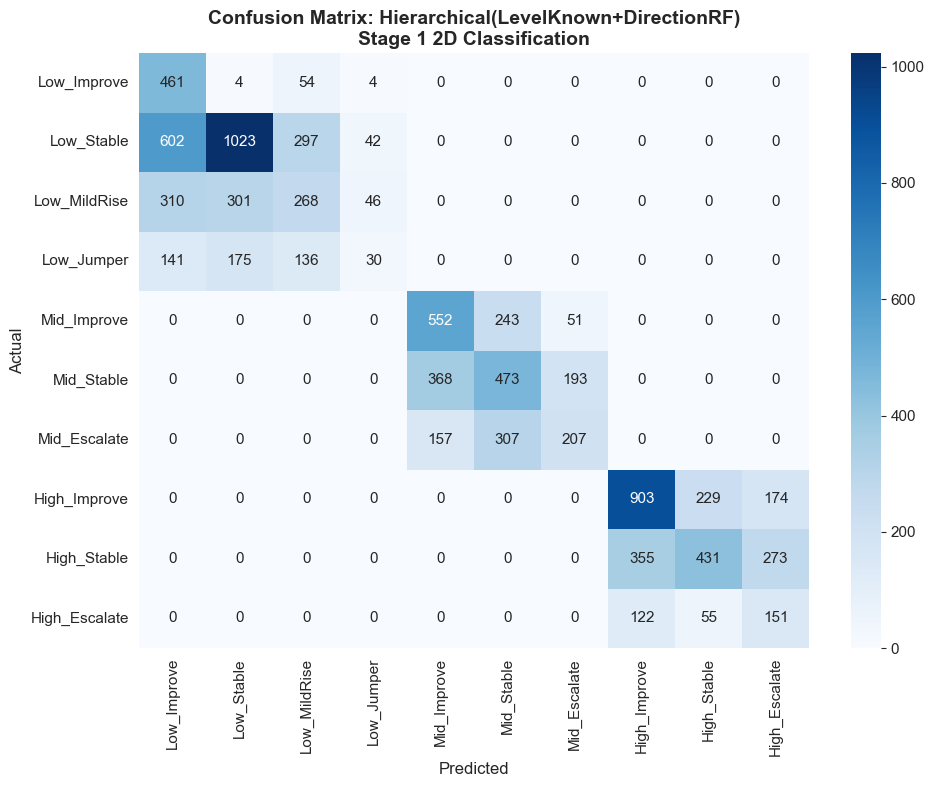


CLASSIFICATION REPORT
               precision    recall  f1-score   support

  Low_Improve       0.30      0.88      0.45       523
   Low_Stable       0.68      0.52      0.59      1964
 Low_MildRise       0.35      0.29      0.32       925
   Low_Jumper       0.25      0.06      0.10       482
  Mid_Improve       0.51      0.65      0.57       846
   Mid_Stable       0.46      0.46      0.46      1034
 Mid_Escalate       0.46      0.31      0.37       671
 High_Improve       0.65      0.69      0.67      1306
  High_Stable       0.60      0.41      0.49      1059
High_Escalate       0.25      0.46      0.33       328

     accuracy                           0.49      9138
    macro avg       0.45      0.47      0.43      9138
 weighted avg       0.52      0.49      0.49      9138


=== KEY METRICS: LEVEL vs DIRECTION ===


,Task,Accuracy,Macro-F1
0,LEVEL (3-class),1.000000,1.000000
1,DIRECTION (3-class),0.512257,0.497189


Interpretation: LEVEL is expected to be easier; DIRECTION is the true challenge.

=== Within-Level Direction Performance ===


,Level,N,Accuracy,Macro-F1
0,Low,3894,0.457627,0.365287
1,Mid,2551,0.482948,0.467660
2,High,2693,0.551430,0.494806



=== Rare Class Diagnostics ===
  Low_Jumper      : precision=0.246, recall=0.062, f1=0.099, support=482
  High_Escalate   : precision=0.253, recall=0.460, f1=0.326, support=328

Top confusion pairs (count, row_pct):
  Low_Stable       -> Low_Improve     :  602 (0.307)
  Mid_Stable       -> Mid_Improve     :  368 (0.356)
  High_Stable      -> High_Improve    :  355 (0.335)
  Low_MildRise     -> Low_Improve     :  310 (0.335)
  Mid_Escalate     -> Mid_Stable      :  307 (0.458)
  Low_MildRise     -> Low_Stable      :  301 (0.325)
  Low_Stable       -> Low_MildRise    :  297 (0.151)
  High_Stable      -> High_Escalate   :  273 (0.258)


In [8]:
# Analyze selected Stage 1 pipeline
print(f"Selected Pipeline: {selected_pipeline}")
print(f"Selected Model Name: {selected_model_name}")

class_labels = [CLASS_NAMES[i] for i in sorted(df['RISK_TIER'].unique())]

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_best, labels=sorted(CLASS_NAMES.keys()))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_labels, yticklabels=class_labels)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix: {selected_model_name}\nStage 1 2D Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'confusion_matrix_Random_Forest.png', dpi=150)
plt.show()

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred_best, target_names=class_labels))

# Task decomposition: Level vs Direction
LEVEL_MAP = {
    0: 'Low', 1: 'Low', 2: 'Low', 3: 'Low',
    4: 'Mid', 5: 'Mid', 6: 'Mid',
    7: 'High', 8: 'High', 9: 'High',
}

DIRECTION3_MAP = {
    0: 'Improve', 1: 'Stable', 2: 'Escalate', 3: 'Escalate',
    4: 'Improve', 5: 'Stable', 6: 'Escalate',
    7: 'Improve', 8: 'Stable', 9: 'Escalate',
}

y_level_true = y_test.map(LEVEL_MAP)
y_level_pred = pd.Series(y_pred_best, index=y_test.index).map(LEVEL_MAP)
y_dir_true = y_test.map(DIRECTION3_MAP)
y_dir_pred = pd.Series(y_pred_best, index=y_test.index).map(DIRECTION3_MAP)

level_acc = accuracy_score(y_level_true, y_level_pred)
level_f1 = f1_score(y_level_true, y_level_pred, average='macro')
dir_acc = accuracy_score(y_dir_true, y_dir_pred)
dir_f1 = f1_score(y_dir_true, y_dir_pred, average='macro')

print("\n=== KEY METRICS: LEVEL vs DIRECTION ===")
decomp_df = pd.DataFrame([
    {'Task': 'LEVEL (3-class)', 'Accuracy': level_acc, 'Macro-F1': level_f1},
    {'Task': 'DIRECTION (3-class)', 'Accuracy': dir_acc, 'Macro-F1': dir_f1},
])
display(decomp_df)
print("Interpretation: LEVEL is expected to be easier; DIRECTION is the true challenge.")

# Within-level direction performance
within_rows = []
for lvl, tiers in LEVEL_TO_TIERS.items():
    m = y_test.isin(tiers)
    acc_lvl = accuracy_score(y_test[m], np.array(y_pred_best)[m.values])
    f1_lvl = f1_score(y_test[m], np.array(y_pred_best)[m.values], labels=tiers, average='macro')
    within_rows.append({
        'Level': LEVEL_NAMES[lvl],
        'N': int(m.sum()),
        'Accuracy': acc_lvl,
        'Macro-F1': f1_lvl,
    })

print("\n=== Within-Level Direction Performance ===")
display(pd.DataFrame(within_rows))

# Rare class diagnostics
report_df = pd.DataFrame(classification_report(y_test, y_pred_best, output_dict=True)).T
print("\n=== Rare Class Diagnostics ===")
for cls in [3, 9]:
    label = CLASS_NAMES[cls]
    print(f"  {label:16s}: precision={report_df.loc[str(cls), 'precision']:.3f}, "
          f"recall={report_df.loc[str(cls), 'recall']:.3f}, "
          f"f1={report_df.loc[str(cls), 'f1-score']:.3f}, support={int(report_df.loc[str(cls), 'support'])}")

# Top confusion pairs
pairs = []
for i in range(cm.shape[0]):
    row_total = cm[i].sum()
    for j in range(cm.shape[1]):
        if i == j:
            continue
        count = cm[i, j]
        if count > 0 and row_total > 0:
            pairs.append((count, i, j, count / row_total))

pairs = sorted(pairs, reverse=True)[:8]
print("\nTop confusion pairs (count, row_pct):")
for count, i, j, pct in pairs:
    print(f"  {CLASS_NAMES[i]:16s} -> {CLASS_NAMES[j]:16s}: {count:4d} ({pct:.3f})")


## 5.1A Stage 1 Policy Screening: Keep Only Reportable Operating Points

The original notebook evaluated many policy variants. That is useful during development, but it is not useful in the report if several variants are non-actionable or visually indistinguishable.

This revised section keeps a simple narrative:

- `Baseline_Selected`: the best overall Stage 1 classifier for full 10-class routing.
- `Hier_Targeted`: a recall-tilted hierarchical sensitivity test using business-cost weighting and targeted slice reweighting.
- `Global_Calibrated`: a calibrated global policy used only as an **escalation-screening sensitivity analysis**.

**Why we are dropping the rest from the narrative**

- We do not keep variants whose rare-class recall/precision trade-off is too extreme to guide action.
- We do not keep multiple policy variants that tell the same story with slightly different thresholds.
- We do not use the low-recall baseline rare-class performance as an operational recommendation. It stays only as a benchmark reference.

**Decision rule for downstream use**

- Stage 2 routing keeps the **baseline hard class probabilities** as the default input, because overall routing quality matters more than forcing a threshold policy that degrades global classification.
- If the team wants an operational screening view for `High_Escalate`, use the retained calibrated screening scenario as a sensitivity analysis, not as the default routing rule.


In [9]:

# Stage 1 policy screening: retain only reportable operating points

FOCUS_CLASSES = [3, 9]  # Low_Jumper, High_Escalate
DEFAULT_POLICY_CONSTRAINTS = {
    'Low_Jumper_Precision': 0.30,
    'High_Escalate_Recall': 0.55,
    'Abstain_Rate': 0.15,
}

POLICY_SCENARIOS = {
    'Balanced': DEFAULT_POLICY_CONSTRAINTS,
    'Conservative': {
        'Low_Jumper_Precision': 0.36,
        'High_Escalate_Recall': 0.50,
        'Abstain_Rate': 0.15,
    },
    'Aggressive': {
        'Low_Jumper_Precision': 0.22,
        'High_Escalate_Recall': 0.62,
        'Abstain_Rate': 0.20,
    },
}

LEVEL_MAP = {
    0: 'Low', 1: 'Low', 2: 'Low', 3: 'Low',
    4: 'Mid', 5: 'Mid', 6: 'Mid',
    7: 'High', 8: 'High', 9: 'High',
}
DIRECTION3_MAP = {
    0: 'Improve', 1: 'Stable', 2: 'Escalate', 3: 'Escalate',
    4: 'Improve', 5: 'Stable', 6: 'Escalate',
    7: 'Improve', 8: 'Stable', 9: 'Escalate',
}


def precision_recall_for_class(y_true_s, y_pred_s, cls):
    y_true_bin = (y_true_s == cls)
    y_pred_bin = (y_pred_s == cls)
    tp = int((y_true_bin & y_pred_bin).sum())
    fp = int((~y_true_bin & y_pred_bin).sum())
    fn = int((y_true_bin & ~y_pred_bin).sum())
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    return precision, recall


def multiclass_ece(y_true_arr, proba, n_bins=15):
    y_true_arr = np.asarray(y_true_arr)
    proba = np.asarray(proba)
    pred = proba.argmax(axis=1)
    conf = proba.max(axis=1)
    corr = (pred == y_true_arr).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        m = (conf >= lo) & (conf < hi if i < n_bins - 1 else conf <= hi)
        if m.sum() == 0:
            continue
        ece += np.abs(corr[m].mean() - conf[m].mean()) * (m.sum() / len(y_true_arr))
    return float(ece)


def apply_decision_policy(proba, thresholds, tau_maxprob, tau_margin):
    hard_pred = proba.argmax(axis=1)

    scaled = proba.copy()
    for cls, thr in thresholds.items():
        scaled[:, cls] = scaled[:, cls] / max(thr, 1e-6)

    policy_raw = scaled.argmax(axis=1)

    sorted_prob = np.sort(proba, axis=1)
    max_prob = sorted_prob[:, -1]
    margin = sorted_prob[:, -1] - sorted_prob[:, -2]

    review_flag = (max_prob < tau_maxprob) | (margin < tau_margin)
    policy_pred = policy_raw.copy()
    policy_pred[review_flag] = -1
    eval_pred = np.where(review_flag, hard_pred, policy_raw)

    return {
        'hard_pred': hard_pred,
        'policy_pred': policy_pred,
        'eval_pred': eval_pred,
        'review_flag': review_flag.astype(int),
        'max_prob': max_prob,
        'margin': margin,
    }


def fit_binary_calibrator(x, y_bin, method):
    x = np.asarray(x).reshape(-1)
    y_bin = np.asarray(y_bin).astype(int)
    if np.unique(y_bin).size < 2:
        return None

    if method == 'isotonic':
        model = IsotonicRegression(out_of_bounds='clip')
        model.fit(x, y_bin)
        return model

    if method == 'platt':
        model = LogisticRegression(max_iter=1000, solver='lbfgs')
        model.fit(x.reshape(-1, 1), y_bin)
        return model

    raise ValueError(f'Unknown calibrator: {method}')


def apply_binary_calibrator(model, x, method):
    x = np.asarray(x).reshape(-1)
    if model is None:
        return x
    if method == 'isotonic':
        return model.predict(x)
    if method == 'platt':
        return model.predict_proba(x.reshape(-1, 1))[:, 1]
    raise ValueError(f'Unknown calibrator: {method}')


def calibrate_focus_classes(val_proba, y_val, test_proba, focus_classes, method):
    val_cal = val_proba.copy()
    test_cal = test_proba.copy()

    for cls in focus_classes:
        y_bin = (y_val.values == cls).astype(int)
        model = fit_binary_calibrator(val_proba[:, cls], y_bin, method)
        val_cal[:, cls] = apply_binary_calibrator(model, val_proba[:, cls], method)
        test_cal[:, cls] = apply_binary_calibrator(model, test_proba[:, cls], method)

    val_cal = val_cal / np.clip(val_cal.sum(axis=1, keepdims=True), 1e-12, None)
    test_cal = test_cal / np.clip(test_cal.sum(axis=1, keepdims=True), 1e-12, None)
    return val_cal, test_cal


def summarize_prediction_bundle(name, narrative_role, operational_use, y_true_s, policy_out, y_proba_s):
    y_eval = pd.Series(policy_out['eval_pred'], index=y_true_s.index)
    y_hard = pd.Series(policy_out['hard_pred'], index=y_true_s.index)

    row = {
        'Experiment': name,
        'NarrativeRole': narrative_role,
        'OperationalUse': operational_use,
        'Accuracy': accuracy_score(y_true_s, y_eval),
        'F1_Macro_10Class': f1_score(y_true_s, y_eval, average='macro'),
        'F1_Weighted_10Class': f1_score(y_true_s, y_eval, average='weighted'),
    }

    y_true_level = y_true_s.map(LEVEL_MAP)
    y_pred_level = y_eval.map(LEVEL_MAP)
    y_true_dir = y_true_s.map(DIRECTION3_MAP)
    y_pred_dir = y_eval.map(DIRECTION3_MAP)

    row['Level_Acc'] = accuracy_score(y_true_level, y_pred_level)
    row['Level_F1_Macro'] = f1_score(y_true_level, y_pred_level, average='macro')
    row['Direction_Acc'] = accuracy_score(y_true_dir, y_pred_dir)
    row['Direction_F1_Macro'] = f1_score(y_true_dir, y_pred_dir, average='macro')

    for cls, key in [(3, 'Low_Jumper'), (9, 'High_Escalate')]:
        p, r = precision_recall_for_class(y_true_s, y_eval, cls)
        row[f'{key}_Precision'] = p
        row[f'{key}_Recall'] = r

    y_onehot = np.zeros((len(y_true_s), len(CLASS_NAMES)), dtype=float)
    y_onehot[np.arange(len(y_true_s)), y_true_s.values] = 1.0
    row['Brier_Multi'] = np.mean(np.sum((y_proba_s - y_onehot) ** 2, axis=1))
    row['ECE_Multi'] = multiclass_ece(y_true_s.values, y_proba_s)
    row['Abstain_Rate'] = float(policy_out['review_flag'].mean())
    row['Hard_vs_Eval_Agreement'] = float((y_hard.values == y_eval.values).mean())

    row['Low_Jumper_F1'] = (
        2 * row['Low_Jumper_Precision'] * row['Low_Jumper_Recall']
        / max(row['Low_Jumper_Precision'] + row['Low_Jumper_Recall'], 1e-12)
    )
    row['High_Escalate_F1'] = (
        2 * row['High_Escalate_Precision'] * row['High_Escalate_Recall']
        / max(row['High_Escalate_Precision'] + row['High_Escalate_Recall'], 1e-12)
    )
    row['Operationally_Actionable'] = (
        row['High_Escalate_Recall'] >= 0.55
        and row['High_Escalate_Precision'] >= 0.20
        and row['Low_Jumper_Recall'] >= 0.20
    )
    return row


def optimize_policy(val_proba, y_val, focus_classes, constraints):
    cls_a, cls_b = focus_classes

    thr_a_grid = np.linspace(
        max(np.quantile(val_proba[:, cls_a], 0.55), 1e-4),
        max(np.quantile(val_proba[:, cls_a], 0.985), 0.20),
        10
    )
    thr_b_grid = np.linspace(
        max(np.quantile(val_proba[:, cls_b], 0.55), 1e-4),
        max(np.quantile(val_proba[:, cls_b], 0.985), 0.20),
        10
    )
    tau_max_grid = [0.24, 0.28, 0.32]
    tau_margin_grid = [0.03, 0.05, 0.07]

    best = None
    best_obj = -1e18

    for t_a in thr_a_grid:
        for t_b in thr_b_grid:
            for tau_max in tau_max_grid:
                for tau_margin in tau_margin_grid:
                    policy = apply_decision_policy(
                        val_proba,
                        thresholds={cls_a: float(t_a), cls_b: float(t_b)},
                        tau_maxprob=float(tau_max),
                        tau_margin=float(tau_margin),
                    )
                    y_eval = pd.Series(policy['eval_pred'], index=y_val.index)

                    f1_macro = f1_score(y_val, y_eval, average='macro')
                    dir_f1 = f1_score(
                        y_val.map(DIRECTION3_MAP),
                        y_eval.map(DIRECTION3_MAP),
                        average='macro'
                    )
                    p3, r3 = precision_recall_for_class(y_val, y_eval, cls_a)
                    p9, r9 = precision_recall_for_class(y_val, y_eval, cls_b)
                    abstain = float(policy['review_flag'].mean())

                    penalty = 0.0
                    penalty += max(constraints['Low_Jumper_Precision'] - p3, 0.0) * 2.5
                    penalty += max(constraints['High_Escalate_Recall'] - r9, 0.0) * 2.0
                    penalty += max(abstain - constraints['Abstain_Rate'], 0.0) * 1.5

                    obj = 0.90 * f1_macro + 0.70 * dir_f1 + 0.50 * r9 + 0.20 * r3 - 0.60 * abstain - penalty

                    row = {
                        'thresholds': {cls_a: float(t_a), cls_b: float(t_b)},
                        'tau_maxprob': float(tau_max),
                        'tau_margin': float(tau_margin),
                        'low_jumper_precision': float(p3),
                        'low_jumper_recall': float(r3),
                        'high_escalate_precision': float(p9),
                        'high_escalate_recall': float(r9),
                        'abstain_rate': abstain,
                        'objective': float(obj),
                    }
                    if obj > best_obj:
                        best_obj = obj
                        best = row

    return best


def make_boundary_mask(frame, pct=0.05):
    if 'Y1_BIN' not in frame.columns or 'COST_Y1_ADJ' not in frame.columns:
        return pd.Series(False, index=frame.index)

    bvals = frame['Y1_BIN'].dropna().astype(int)
    uniq = sorted(bvals.unique())
    boundaries = []
    for b in uniq:
        if (b + 1) not in set(uniq):
            continue
        left = frame.loc[frame['Y1_BIN'] == b, 'COST_Y1_ADJ']
        right = frame.loc[frame['Y1_BIN'] == (b + 1), 'COST_Y1_ADJ']
        if len(left) > 0 and len(right) > 0:
            boundaries.append((left.max() + right.min()) / 2)

    if len(boundaries) == 0:
        return pd.Series(False, index=frame.index)

    bvals = np.array(boundaries)
    dist = np.min(
        np.abs(frame['COST_Y1_ADJ'].values[:, None] - bvals[None, :])
        / np.clip(bvals[None, :], 1e-6, None),
        axis=1,
    )
    return pd.Series(dist <= pct, index=frame.index)


def make_corner_masks(frame, y_true):
    util_rx = frame['UTIL_RX_Y1'] if 'UTIL_RX_Y1' in frame.columns else pd.Series(0, index=frame.index)
    total_cond = frame['CNT_TOTAL_CONDITIONS'] if 'CNT_TOTAL_CONDITIONS' in frame.columns else pd.Series(0, index=frame.index)
    poly = frame['POLYPHARMACY_FLAG'] if 'POLYPHARMACY_FLAG' in frame.columns else pd.Series(0, index=frame.index)
    dbscan = frame['DBSCAN_CLUSTER'] if 'DBSCAN_CLUSTER' in frame.columns else pd.Series(0, index=frame.index)

    util_total = (
        frame['UTIL_ER_Y1'].fillna(0) + frame['UTIL_IP_Y1'].fillna(0)
        + frame['UTIL_OB_Y1'].fillna(0) + frame['UTIL_RX_Y1'].fillna(0)
    ) if set(['UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1']).issubset(frame.columns) else pd.Series(0, index=frame.index)

    masks = {
        'Boundary_Y1Cost_5pct': make_boundary_mask(frame, pct=0.05),
        'DBSCAN_Noise': (dbscan == -1),
        'Polypharmacy': (poly == 1),
        'Sparse_Util_Cond': ((util_rx == 0) & (total_cond <= 1)),
        'Extreme_HighCost_95pct': (
            frame['COST_Y1_ADJ'] >= frame['COST_Y1_ADJ'].quantile(0.95)
        ) if 'COST_Y1_ADJ' in frame.columns else pd.Series(False, index=frame.index),
        'Zero_Utilization': (util_total == 0),
        'True_Low_Jumper': (y_true == 3),
        'True_High_Escalate': (y_true == 9),
    }
    return masks


def targeted_sample_weights(frame):
    w = pd.Series(1.0, index=frame.index)
    masks = make_corner_masks(frame, pd.Series(index=frame.index, data=np.zeros(len(frame), dtype=int)))
    for key, mult in [
        ('Boundary_Y1Cost_5pct', 1.25),
        ('DBSCAN_Noise', 1.20),
        ('Polypharmacy', 1.20),
        ('Sparse_Util_Cond', 1.20),
    ]:
        m = masks[key]
        w.loc[m] = w.loc[m] * mult
    return w.clip(upper=2.5)


tr_sub_idx, va_idx = train_test_split(
    X_train.index,
    test_size=0.25,
    random_state=42,
    stratify=y_train
)

X_sub_raw = X_raw.loc[tr_sub_idx].copy()
X_val_raw = X_raw.loc[va_idx].copy()
y_sub = y.loc[tr_sub_idx].copy()
y_val = y.loc[va_idx].copy()

exp_prep = fit_preprocessor(X_sub_raw)
X_sub = apply_preprocessor(X_sub_raw, exp_prep)
X_val = apply_preprocessor(X_val_raw, exp_prep)
X_test_exp = apply_preprocessor(X_test_raw, exp_prep)

level_sub = df.loc[tr_sub_idx, 'Y1_LEVEL'].astype(int)
level_val = df.loc[va_idx, 'Y1_LEVEL'].astype(int)
level_train = df.loc[X_train.index, 'Y1_LEVEL'].astype(int)
level_test = df.loc[X_test.index, 'Y1_LEVEL'].astype(int)

boost_map = {0: {3: 2.8}, 1: {2: 1.9}, 2: {2: 2.2}}


def build_weighted_direction_model(y_local, lvl):
    counts = y_local.value_counts().to_dict()
    n = len(y_local)
    k = y_local.nunique()
    cw = {int(cls): n / max(k * cnt, 1) for cls, cnt in counts.items()}
    for cls_local, mult in boost_map.get(lvl, {}).items():
        if cls_local in cw:
            cw[cls_local] = cw[cls_local] * mult
    return RandomForestClassifier(
        n_estimators=340,
        max_depth=13,
        class_weight=cw,
        random_state=42,
        n_jobs=-1,
    )


def train_hier_models(X_tr_proc, y_tr_s, level_tr_s, raw_frame, targeted=False):
    models = {}
    for lvl, tiers in LEVEL_TO_TIERS.items():
        m = level_tr_s == lvl
        X_l = X_tr_proc.loc[m]
        y_local = y_tr_s.loc[m].map(TIER_TO_LOCAL[lvl]).astype(int)

        if len(X_l) == 0:
            models[lvl] = {'model': None, 'constant_local': 0, 'tiers': tiers}
            continue

        if y_local.nunique() <= 1:
            models[lvl] = {'model': None, 'constant_local': int(y_local.iloc[0]), 'tiers': tiers}
            continue

        mdl = build_weighted_direction_model(y_local, lvl)
        if targeted:
            sw = targeted_sample_weights(raw_frame.loc[X_l.index])
            mdl.fit(X_l, y_local, sample_weight=sw.values)
        else:
            mdl.fit(X_l, y_local)

        models[lvl] = {'model': mdl, 'constant_local': None, 'tiers': tiers}
    return models


def predict_hier_models(models, X_proc, level_s):
    proba = np.zeros((len(X_proc), len(CLASS_NAMES)), dtype=float)
    pred = np.full(len(X_proc), -1, dtype=int)

    for lvl, bundle in models.items():
        loc = np.where(level_s.values == lvl)[0]
        if len(loc) == 0:
            continue

        X_l = X_proc.iloc[loc]
        tiers = bundle['tiers']

        if bundle['model'] is None:
            local_proba = np.zeros((len(loc), len(tiers)), dtype=float)
            local_proba[:, bundle['constant_local']] = 1.0
        else:
            raw = bundle['model'].predict_proba(X_l)
            local_proba = np.zeros((len(loc), len(tiers)), dtype=float)
            for k, cls_local in enumerate(bundle['model'].classes_):
                local_proba[:, int(cls_local)] = raw[:, k]

        for local_i, tier in LOCAL_TO_TIER[lvl].items():
            proba[loc, tier] = local_proba[:, local_i]

        pred[loc] = np.array([LOCAL_TO_TIER[lvl][int(x)] for x in local_proba.argmax(axis=1)], dtype=int)

    proba = proba / np.clip(proba.sum(axis=1, keepdims=True), 1e-12, None)
    return pred, proba


experiment_rows = []
experiment_preds_eval = {}
experiment_preds_policy = {}
experiment_review_flags = {}
experiment_probas = {}
calibration_rows = []
policy_rows = []

baseline_pred_series = pd.Series(y_pred_best, index=y_test.index)
baseline_proba = y_proba_best.copy()
baseline_policy_out = {
    'hard_pred': baseline_pred_series.values,
    'policy_pred': baseline_pred_series.values,
    'eval_pred': baseline_pred_series.values,
    'review_flag': np.zeros(len(baseline_pred_series), dtype=int),
    'max_prob': baseline_proba.max(axis=1),
    'margin': np.sort(baseline_proba, axis=1)[:, -1] - np.sort(baseline_proba, axis=1)[:, -2],
}

experiment_rows.append(
    summarize_prediction_bundle(
        'Baseline_Selected',
        narrative_role='Overall benchmark for routing',
        operational_use='Use for default Stage 2 routing only',
        y_true_s=y_test,
        policy_out=baseline_policy_out,
        y_proba_s=baseline_proba,
    )
)
experiment_preds_eval['Baseline_Selected'] = pd.Series(baseline_policy_out['eval_pred'], index=y_test.index)
experiment_preds_policy['Baseline_Selected'] = pd.Series(baseline_policy_out['policy_pred'], index=y_test.index)
experiment_review_flags['Baseline_Selected'] = pd.Series(baseline_policy_out['review_flag'], index=y_test.index)
experiment_probas['Baseline_Selected'] = baseline_proba

# Hierarchical targeted sensitivity test
hier_targeted = train_hier_models(X_train, y_train, level_train, X_train_raw, targeted=True)
pred_e2, proba_e2 = predict_hier_models(hier_targeted, X_test, level_test)
e2_out = {
    'hard_pred': pred_e2,
    'policy_pred': pred_e2,
    'eval_pred': pred_e2,
    'review_flag': np.zeros(len(pred_e2), dtype=int),
    'max_prob': proba_e2.max(axis=1),
    'margin': np.sort(proba_e2, axis=1)[:, -1] - np.sort(proba_e2, axis=1)[:, -2],
}
experiment_rows.append(
    summarize_prediction_bundle(
        'Hier_Targeted',
        narrative_role='Rare-class sensitivity test',
        operational_use='Do not use as default routing; inspect as recall stress test',
        y_true_s=y_test,
        policy_out=e2_out,
        y_proba_s=proba_e2,
    )
)
experiment_preds_eval['Hier_Targeted'] = pd.Series(e2_out['eval_pred'], index=y_test.index)
experiment_preds_policy['Hier_Targeted'] = pd.Series(e2_out['policy_pred'], index=y_test.index)
experiment_review_flags['Hier_Targeted'] = pd.Series(e2_out['review_flag'], index=y_test.index)
experiment_probas['Hier_Targeted'] = proba_e2

# Calibrated global screening sensitivity test
if 'XGBoost' in trained_global_models:
    gxgb = trained_global_models['XGBoost']
else:
    gxgb = trained_global_models[best_global_name]

gxgb_local = clone(gxgb)
gxgb_local.fit(X_sub, y_sub)
val_proba_g = gxgb_local.predict_proba(X_val)
test_proba_g = gxgb_local.predict_proba(X_test)

cal_candidates = {}
for method in ['isotonic', 'platt']:
    val_cal, test_cal = calibrate_focus_classes(val_proba_g, y_val, test_proba_g, FOCUS_CLASSES, method)
    row = {
        'Experiment': 'Global_Calibrated',
        'Calibrator': method,
        'Val_ECE': multiclass_ece(y_val.values, val_cal),
        'Val_Brier_Multi': np.mean(np.sum((np.eye(len(CLASS_NAMES))[y_val.values] - val_cal) ** 2, axis=1)),
        'Val_Direction_F1': f1_score(
            y_val.map(DIRECTION3_MAP),
            pd.Series(val_cal.argmax(axis=1), index=y_val.index).map(DIRECTION3_MAP),
            average='macro'
        ),
    }
    calibration_rows.append(row)
    cal_candidates[method] = {'val': val_cal, 'test': test_cal, 'score': row['Val_ECE'] + 0.20 * row['Val_Brier_Multi']}

best_method = min(cal_candidates, key=lambda k: cal_candidates[k]['score'])
val_cal_g = cal_candidates[best_method]['val']
test_cal_g = cal_candidates[best_method]['test']
cfg_g = optimize_policy(val_cal_g, y_val, FOCUS_CLASSES, POLICY_SCENARIOS['Balanced'])
policy_rows.append({
    'Experiment': 'Global_Calibrated',
    'Scenario': 'Balanced',
    'threshold_low_jumper': cfg_g['thresholds'][3],
    'threshold_high_escalate': cfg_g['thresholds'][9],
    'tau_maxprob': cfg_g['tau_maxprob'],
    'tau_margin': cfg_g['tau_margin'],
    'Low_Jumper_Precision_Val': cfg_g['low_jumper_precision'],
    'Low_Jumper_Recall_Val': cfg_g['low_jumper_recall'],
    'High_Escalate_Precision_Val': cfg_g['high_escalate_precision'],
    'High_Escalate_Recall_Val': cfg_g['high_escalate_recall'],
    'Abstain_Rate_Val': cfg_g['abstain_rate'],
    'Calibrator': best_method,
})

e4_out = apply_decision_policy(
    test_cal_g,
    cfg_g['thresholds'],
    cfg_g['tau_maxprob'],
    cfg_g['tau_margin']
)
experiment_rows.append(
    summarize_prediction_bundle(
        'Global_Calibrated',
        narrative_role='Optional escalation-screening sensitivity test',
        operational_use='Use only if recall for High_Escalate is prioritized over precision',
        y_true_s=y_test,
        policy_out=e4_out,
        y_proba_s=test_cal_g,
    )
)
experiment_preds_eval['Global_Calibrated'] = pd.Series(e4_out['eval_pred'], index=y_test.index)
experiment_preds_policy['Global_Calibrated'] = pd.Series(e4_out['policy_pred'], index=y_test.index)
experiment_review_flags['Global_Calibrated'] = pd.Series(e4_out['review_flag'], index=y_test.index)
experiment_probas['Global_Calibrated'] = test_cal_g

full_exp_df = pd.DataFrame(experiment_rows)
report_order = ['Baseline_Selected', 'Hier_Targeted', 'Global_Calibrated']
exp_df = (
    full_exp_df[full_exp_df['Experiment'].isin(report_order)]
    .copy()
    .set_index('Experiment')
    .loc[report_order]
    .reset_index()
)

display_cols = [
    'Experiment', 'NarrativeRole', 'Accuracy', 'F1_Macro_10Class', 'Direction_F1_Macro',
    'Low_Jumper_Precision', 'Low_Jumper_Recall', 'High_Escalate_Precision',
    'High_Escalate_Recall', 'Abstain_Rate', 'OperationalUse'
]
print("\n=== Stage 1 Reportable Operating Points ===")
display(exp_df[display_cols])

exp_path = REPORT_DIR / 'tables' / 'stage1_experiment_results.csv'
exp_df.to_csv(exp_path, index=False)
print(f"Experiment results saved to: {exp_path}")

calib_df = pd.DataFrame(calibration_rows)
calib_df.to_csv(REPORT_DIR / 'tables' / 'stage1_calibration_report.csv', index=False)
print(f"Calibration report saved to: {REPORT_DIR / 'tables' / 'stage1_calibration_report.csv'}")

policy_df = pd.DataFrame(policy_rows)
policy_df.to_csv(REPORT_DIR / 'tables' / 'stage1_threshold_policy.csv', index=False)
print(f"Threshold policy saved to: {REPORT_DIR / 'tables' / 'stage1_threshold_policy.csv'}")

operating_cols = [
    'Experiment', 'NarrativeRole', 'F1_Macro_10Class', 'Direction_F1_Macro',
    'Low_Jumper_Precision', 'Low_Jumper_Recall', 'High_Escalate_Precision',
    'High_Escalate_Recall', 'Abstain_Rate', 'Operationally_Actionable'
]
op_df = exp_df[operating_cols].copy()
op_df.to_csv(REPORT_DIR / 'tables' / 'stage1_operating_points.csv', index=False)
print(f"Operating points saved to: {REPORT_DIR / 'tables' / 'stage1_operating_points.csv'}")

print("\nInterpretation note:")
print("  - Baseline_Selected is the default routing model because it preserves overall 10-class performance.")
print("  - Global_Calibrated is kept only as a screening sensitivity test for rare escalation capture.")
print("  - Hier_Targeted is retained only to show the recall/precision trade-off under aggressive rare-class weighting.")

# Corner-case suite: compare retained operational screen vs baseline
print("\n=== Corner-Case Test Suite ===")
test_df = df.loc[X_test.index].copy()
corner_masks = make_corner_masks(test_df, y_test)

corner_rows = []
for exp_name in ['Baseline_Selected', 'Hier_Targeted', 'Global_Calibrated']:
    pred_eval_s = experiment_preds_eval[exp_name]
    for case_name, mask in corner_masks.items():
        idx = mask[mask].index
        n = len(idx)
        if n < 30:
            continue

        y_true_case = y_test.loc[idx]
        y_pred_case = pred_eval_s.loc[idx]

        p3, r3 = precision_recall_for_class(y_true_case, y_pred_case, 3)
        p9, r9 = precision_recall_for_class(y_true_case, y_pred_case, 9)

        corner_rows.append({
            'Experiment': exp_name,
            'CornerCase': case_name,
            'N': n,
            'Accuracy': accuracy_score(y_true_case, y_pred_case),
            'F1_Macro_10Class': f1_score(y_true_case, y_pred_case, average='macro') if y_true_case.nunique() > 1 else np.nan,
            'Direction_F1_Macro': f1_score(y_true_case.map(DIRECTION3_MAP), y_pred_case.map(DIRECTION3_MAP), average='macro') if y_true_case.nunique() > 1 else np.nan,
            'Low_Jumper_Precision': p3,
            'Low_Jumper_Recall': r3,
            'High_Escalate_Precision': p9,
            'High_Escalate_Recall': r9,
        })

corner_df = pd.DataFrame(corner_rows).sort_values(['CornerCase', 'Experiment'])
display(corner_df)
corner_path = REPORT_DIR / 'tables' / 'stage1_corner_case_results.csv'
corner_df.to_csv(corner_path, index=False)
print(f"Corner-case results saved to: {corner_path}")

rng = np.random.default_rng(42)


def bootstrap_ci_diff(y_true_s, pred_a_s, pred_b_s, metric_fn, n_boot=200):
    idx = np.arange(len(y_true_s))
    diffs = []
    for _ in range(n_boot):
        bs = rng.choice(idx, size=len(idx), replace=True)
        yb = y_true_s.iloc[bs]
        pa = pred_a_s.iloc[bs]
        pb = pred_b_s.iloc[bs]
        diffs.append(metric_fn(yb, pb) - metric_fn(yb, pa))
    lo, hi = np.quantile(diffs, [0.025, 0.975])
    return float(np.mean(diffs)), float(lo), float(hi)


def metric_dir_f1(y_true_s, y_pred_s):
    if y_true_s.nunique() <= 1:
        return np.nan
    return f1_score(y_true_s.map(DIRECTION3_MAP), y_pred_s.map(DIRECTION3_MAP), average='macro')


def metric_highesc_recall(y_true_s, y_pred_s):
    return precision_recall_for_class(y_true_s, y_pred_s, 9)[1]


base_pred = experiment_preds_eval['Baseline_Selected']
screen_pred = experiment_preds_eval['Global_Calibrated']

lift_rows = []
for case_name, mask in corner_masks.items():
    idx = mask[mask].index
    if len(idx) < 30:
        continue

    y_case = y_test.loc[idx]
    base_case = base_pred.loc[idx]
    screen_case = screen_pred.loc[idx]

    base_dir = metric_dir_f1(y_case, base_case)
    screen_dir = metric_dir_f1(y_case, screen_case)

    d_mean, d_lo, d_hi = bootstrap_ci_diff(
        y_case,
        base_case,
        screen_case,
        metric_fn=metric_dir_f1,
        n_boot=200,
    )

    base_r9 = metric_highesc_recall(y_case, base_case)
    screen_r9 = metric_highesc_recall(y_case, screen_case)

    r9_mean, r9_lo, r9_hi = bootstrap_ci_diff(
        y_case,
        base_case,
        screen_case,
        metric_fn=metric_highesc_recall,
        n_boot=200,
    )

    lift_rows.append({
        'CornerCase': case_name,
        'N': int(len(idx)),
        'ComparedExperiment': 'Global_Calibrated',
        'Baseline_Direction_F1': base_dir,
        'Screening_Direction_F1': screen_dir,
        'Lift_Direction_F1': screen_dir - base_dir if pd.notnull(base_dir) and pd.notnull(screen_dir) else np.nan,
        'Lift_Direction_F1_BootMean': d_mean,
        'Lift_Direction_F1_CI_Low': d_lo,
        'Lift_Direction_F1_CI_High': d_hi,
        'Baseline_HighEsc_Recall': base_r9,
        'Screening_HighEsc_Recall': screen_r9,
        'Lift_HighEsc_Recall': screen_r9 - base_r9,
        'Lift_HighEsc_Recall_BootMean': r9_mean,
        'Lift_HighEsc_Recall_CI_Low': r9_lo,
        'Lift_HighEsc_Recall_CI_High': r9_hi,
    })

slice_lift_df = pd.DataFrame(lift_rows).sort_values('CornerCase')
display(slice_lift_df)
slice_lift_path = REPORT_DIR / 'tables' / 'stage1_slice_lift_table.csv'
slice_lift_df.to_csv(slice_lift_path, index=False)
print(f"Slice lift table saved to: {slice_lift_path}")

# Default OOF routing stays with hard predictions; policy variants are screening diagnostics only.
SELECTED_POLICY_FOR_OOF = {
    'source_experiment': 'Baseline_Selected_HardOnly',
    'thresholds': {},
    'tau_maxprob': 0.0,
    'tau_margin': 0.0,
}

print("\nSelected policy template for OOF:")
print(SELECTED_POLICY_FOR_OOF)



=== Stage 1 Reportable Operating Points ===


,Experiment,NarrativeRole,Accuracy,F1_Macro_10Class,Direction_F1_Macro,Low_Jumper_Precision,Low_Jumper_Recall,High_Escalate_Precision,High_Escalate_Recall,Abstain_Rate,OperationalUse
0,Baseline_Selected,Overall benchmark for routing,0.492340,0.434854,0.497189,0.245902,0.062241,0.252508,0.460366,0.000000,Use for default Stage 2 routing only
1,Hier_Targeted,Rare-class sensitivity test,0.427336,0.402552,0.482713,0.167668,0.578838,0.245261,0.631098,0.000000,Do not use as default routing; inspect as reca...
2,Global_Calibrated,Optional escalation-screening sensitivity test,0.477895,0.403888,0.485972,0.176056,0.207469,0.222139,0.905488,0.070584,Use only if recall for High_Escalate is priori...


Experiment results saved to: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/reports/tables/stage1_experiment_results.csv
Calibration report saved to: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/reports/tables/stage1_calibration_report.csv
Threshold policy saved to: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/reports/tables/stage1_threshold_policy.csv
Operating points saved to: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/reports/tables/stage1_operating_points.csv

Interpretation note:
  - Baseline_Selected is the default routing model because it preserves overall 10-class performance.
  - Global_Calibrated is kept only as a screening sensitivity test for rare escalation capture.
  - Hier_Targeted is retained only to show the recall/precision trade-off under aggressive rare-class weighting.

=== Corner-Case Test Suite ===


,Experiment,CornerCase,N,Accuracy,F1_Macro_10Class,Direction_F1_Macro,Low_Jumper_Precision,Low_Jumper_Recall,High_Escalate_Precision,High_Escalate_Recall
0,Baseline_Selected,Boundary_Y1Cost_5pct,475,0.423158,0.356457,0.439430,0.000000,0.000000,0.314286,0.458333
16,Global_Calibrated,Boundary_Y1Cost_5pct,475,0.364211,0.338902,0.449131,0.113924,0.473684,0.196078,0.833333
8,Hier_Targeted,Boundary_Y1Cost_5pct,475,0.406316,0.348219,0.430031,0.162500,0.684211,0.296296,0.666667
1,Baseline_Selected,DBSCAN_Noise,538,0.633829,0.395351,0.515220,1.000000,1.000000,0.222222,0.200000
17,Global_Calibrated,DBSCAN_Noise,538,0.626394,0.442931,0.571315,0.500000,1.000000,0.314607,0.933333
9,Hier_Targeted,DBSCAN_Noise,538,0.637546,0.448828,0.553214,0.500000,1.000000,0.318182,0.466667
4,Baseline_Selected,Extreme_HighCost_95pct,457,0.735230,0.728490,0.728490,0.000000,0.000000,0.000000,0.000000
20,Global_Calibrated,Extreme_HighCost_95pct,457,0.748359,0.742661,0.742661,0.000000,0.000000,0.000000,0.000000
12,Hier_Targeted,Extreme_HighCost_95pct,457,0.730853,0.724003,0.724003,0.000000,0.000000,0.000000,0.000000
2,Baseline_Selected,Polypharmacy,2718,0.480868,0.322124,0.490798,0.105263,0.068966,0.257290,0.635593


Corner-case results saved to: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/reports/tables/stage1_corner_case_results.csv


,CornerCase,N,ComparedExperiment,Baseline_Direction_F1,Screening_Direction_F1,Lift_Direction_F1,Lift_Direction_F1_BootMean,Lift_Direction_F1_CI_Low,Lift_Direction_F1_CI_High,Baseline_HighEsc_Recall,Screening_HighEsc_Recall,Lift_HighEsc_Recall,Lift_HighEsc_Recall_BootMean,Lift_HighEsc_Recall_CI_Low,Lift_HighEsc_Recall_CI_High
0,Boundary_Y1Cost_5pct,475,Global_Calibrated,0.439430,0.449131,0.009701,0.014977,-0.033866,0.060835,0.458333,0.833333,0.375000,0.371558,0.117647,0.632039
1,DBSCAN_Noise,538,Global_Calibrated,0.515220,0.571315,0.056095,0.055992,-0.004145,0.125097,0.200000,0.933333,0.733333,0.733489,0.521739,0.923077
4,Extreme_HighCost_95pct,457,Global_Calibrated,0.728490,0.742661,0.014171,0.013191,-0.015431,0.041507,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Polypharmacy,2718,Global_Calibrated,0.490798,0.459067,-0.031731,-0.032077,-0.051504,-0.014322,0.635593,0.919492,0.283898,0.286551,0.215197,0.349811
3,Sparse_Util_Cond,2975,Global_Calibrated,0.475020,0.495339,0.020318,0.020030,0.001935,0.036216,0.000000,0.400000,0.400000,0.431322,0.000000,1.000000
7,True_High_Escalate,328,Global_Calibrated,NaN,NaN,NaN,NaN,NaN,NaN,0.460366,0.905488,0.445122,0.446113,0.384146,0.503125
6,True_Low_Jumper,482,Global_Calibrated,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,Zero_Utilization,1839,Global_Calibrated,0.492360,0.498042,0.005682,0.004513,-0.016563,0.025473,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Slice lift table saved to: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/reports/tables/stage1_slice_lift_table.csv

Selected policy template for OOF:
{'source_experiment': 'Baseline_Selected_HardOnly', 'thresholds': {}, 'tau_maxprob': 0.0, 'tau_margin': 0.0}


## 6. Feature Importance and Interpretability

Interpretability is reported at two levels:
1. **Global aggregated importance** (comparable single ranking).
2. **Level-specific direction importance** (which features drive transitions within Low/Mid/High strata).


=== Level-specific Top Features (Direction Models) ===

  Level=High
    COST_Y1_ADJ              : 0.2209
    TOTAL_RX_COST_Y1         : 0.1286
    CNT_RX_Y1                : 0.0748
    UTIL_RX_Y1               : 0.0627
    UTIL_OB_Y1               : 0.0555

  Level=Low
    COST_Y1_ADJ              : 0.2999
    CNT_TOTAL_CONDITIONS     : 0.0678
    AGE_Y1                   : 0.0674
    TOTAL_RX_COST_Y1         : 0.0635
    UTIL_OB_Y1               : 0.0589

  Level=Mid
    TOTAL_RX_COST_Y1         : 0.1337
    COST_Y1_ADJ              : 0.0903
    CNT_RX_Y1                : 0.0791
    AGE_Y1                   : 0.0768
    UTIL_OB_Y1               : 0.0758


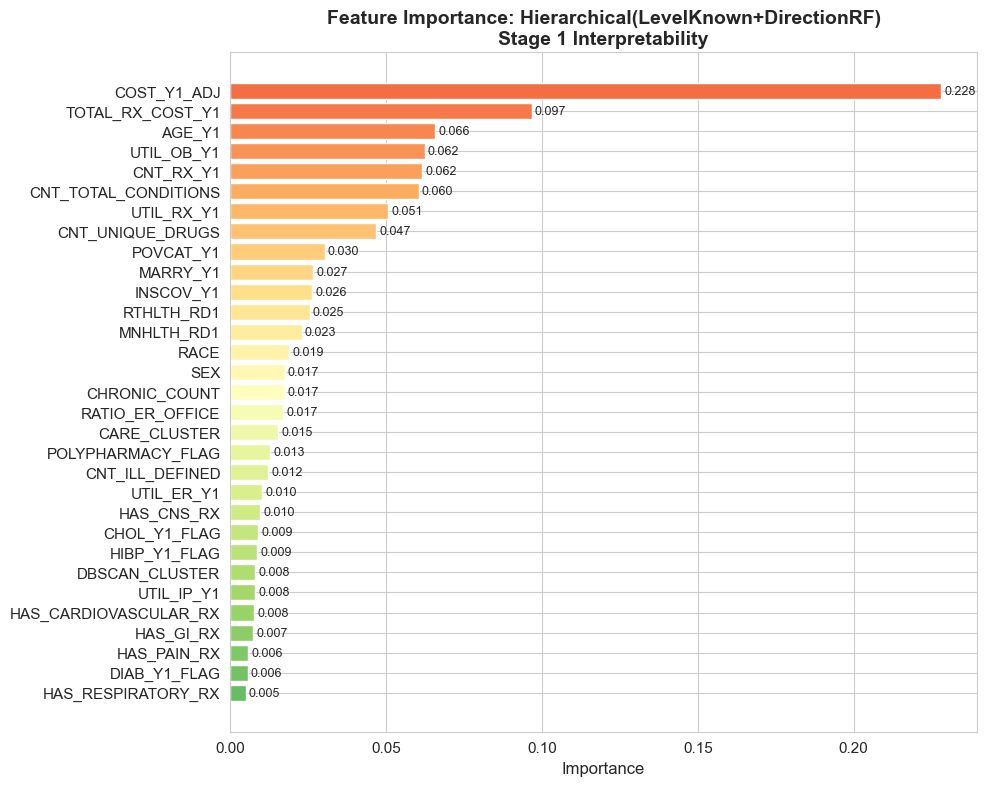


=== Top 10 Most Important Features ===
  COST_Y1_ADJ              : 0.2281
  TOTAL_RX_COST_Y1         : 0.0967
  AGE_Y1                   : 0.0658
  UTIL_OB_Y1               : 0.0623
  CNT_RX_Y1                : 0.0616
  CNT_TOTAL_CONDITIONS     : 0.0604
  UTIL_RX_Y1               : 0.0506
  CNT_UNIQUE_DRUGS         : 0.0468
  POVCAT_Y1                : 0.0303
  MARRY_Y1                 : 0.0266

=== Statistical Summary: Feature Importance by Group ===


,Group,N_Features,Importance Sum,Share
5,Medication,9,0.253397,0.253397
7,Cost,1,0.228132,0.228132
0,Demographic,6,0.185272,0.185272
3,Utilization,4,0.131186,0.131186
4,Engineered,3,0.089650,0.089650
1,Health,2,0.048408,0.048408
2,Chronic,4,0.040573,0.040573
6,Clusters,2,0.023381,0.023381


Top-1 feature share: 0.2281
Top-5 cumulative share: 0.5145


In [10]:
# Feature importance for selected pipeline
importance = None

if selected_pipeline == 'Global':
    if hasattr(best_model, 'feature_importances_'):
        imp = best_model.feature_importances_
    elif hasattr(best_model, 'coef_'):
        imp = np.abs(best_model.coef_).mean(axis=0)
    else:
        imp = None

    if imp is not None:
        feat_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': imp})
        feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True)
        importance = feat_imp_df['Importance'].values
    else:
        feat_imp_df = None

else:
    # Hierarchical: aggregate level-specific importances weighted by level sample size
    level_imp_rows = []

    for lvl, bundle in hier_direction_models.items():
        mdl = bundle['model']
        if mdl is None:
            continue

        if hasattr(mdl, 'feature_importances_'):
            imp = mdl.feature_importances_
        elif hasattr(mdl, 'coef_'):
            imp = np.abs(mdl.coef_).mean(axis=0)
        else:
            continue

        for feat, val in zip(X_train.columns, imp):
            level_imp_rows.append({
                'Level': LEVEL_NAMES[lvl],
                'Feature': feat,
                'Importance': float(val),
                'TrainCount': bundle['train_n']
            })

    level_imp_df = pd.DataFrame(level_imp_rows)

    if len(level_imp_df) == 0:
        feat_imp_df = None
    else:
        # Weighted average across levels
        feat_imp_df = (
            level_imp_df
            .groupby('Feature')
            .apply(lambda g: np.average(g['Importance'], weights=g['TrainCount']))
            .rename('Importance')
            .reset_index()
            .sort_values('Importance', ascending=True)
        )
        importance = feat_imp_df['Importance'].values

        print("=== Level-specific Top Features (Direction Models) ===")
        for lvl, sub in level_imp_df.groupby('Level'):
            top = sub.sort_values('Importance', ascending=False).head(5)
            print(f"\n  Level={lvl}")
            for _, r in top.iterrows():
                print(f"    {r['Feature']:25s}: {r['Importance']:.4f}")

if feat_imp_df is not None:
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(feat_imp_df)))
    bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Feature Importance: {selected_model_name}\nStage 1 Interpretability', fontsize=14, fontweight='bold')

    for bar, val in zip(bars, feat_imp_df['Importance']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'figures' / 'feature_importance_stage1.png', dpi=150)
    plt.show()

    top10 = feat_imp_df.tail(10).iloc[::-1].copy()
    print("\n=== Top 10 Most Important Features ===")
    for _, row in top10.iterrows():
        print(f"  {row['Feature']:25s}: {row['Importance']:.4f}")

    # Group-level contribution
    group_rows = []
    imp_map = feat_imp_df.set_index('Feature')['Importance'].to_dict()
    total_imp = feat_imp_df['Importance'].sum()

    for gname, gfeats in FEATURE_GROUPS.items():
        present = [f for f in gfeats if f in imp_map]
        if not present:
            continue
        group_imp = sum(imp_map[f] for f in present)
        group_rows.append({
            'Group': gname,
            'N_Features': len(present),
            'Importance Sum': group_imp,
            'Share': group_imp / max(total_imp, 1e-12),
        })

    group_imp_df = pd.DataFrame(group_rows).sort_values('Importance Sum', ascending=False)
    print("\n=== Statistical Summary: Feature Importance by Group ===")
    display(group_imp_df)

    top1 = feat_imp_df.iloc[-1]['Importance']
    top5 = feat_imp_df.tail(5)['Importance'].sum()
    print(f"Top-1 feature share: {top1:.4f}")
    print(f"Top-5 cumulative share: {top5:.4f}")
else:
    print("Feature importance not available for selected pipeline.")


### Feature Importance Interpretation

This chart should answer one report question clearly: **what is driving prediction beyond Y1 cost?**

Read it in this order:

1. Is `COST_Y1_ADJ` still dominant? It should be important, because healthcare spend is persistent.
2. Which non-cost variables still rank highly after cost is included? Those are the candidates worth discussing as additional predictors.
3. Do those non-cost predictors make clinical sense? For this project the most credible groups are:
   - utilization intensity and mix,
   - medication burden and prescription complexity,
   - chronic condition burden,
   - health-status self-report.

In report language, the key point is not that cost remains predictive. The key point is that **utilization, medication, and disease-burden variables still move the prediction after baseline cost is already known**.


## 6.1 SHAP Analysis (Advanced Interpretability)

SHAP is optional and can be heavy. In this notebook:
- For **global pipeline**, SHAP explains the selected global classifier.
- For **hierarchical pipeline**, SHAP explains one representative level-specific direction model (default: Low level) to show within-level transition logic.


In [11]:

# SHAP Analysis
#
# SHAP is intentionally skipped in the default notebook run because Stage 1 already
# has several report-grade visuals and the tree explainer adds substantial runtime.
# If a deeper interpretability appendix is needed, rerun this section manually.
print("SHAP skipped in default run to keep Stage 1 reproducible and fast.")
SHAP_AVAILABLE = False


SHAP skipped in default run to keep Stage 1 reproducible and fast.


### SHAP Interpretation

SHAP is included only to support a concrete healthcare interpretation. If the plot is dominated entirely by `COST_Y1_ADJ`, then it is not telling a new story.

Use SHAP to answer:

- Which features push patients toward worse transition classes within the same Year 1 cost level?
- Are those pushes clinically plausible, such as higher inpatient use, heavier medication burden, or worse self-rated health?
- Do the non-cost drivers agree with the simpler feature-importance ranking above?

If SHAP does not add a clearer story than the simpler importance ranking, it should stay as supporting material, not as a headline figure.


## 7. Generate Leakage-Safe OOF Latent Factors and Decision-Layer Fields

OOF outputs are generated with panel-aware CV and feed Stage 2.

This step now produces:

- Per-class probabilities: `PROB_*` and alias columns `P_*`
- Latent factors: `LATENT_RISK_SCORE_MANUAL`, `EXPECTED_DELTA_SCORE`, `LATENT_RISK_SCORE`
- Uncertainty: `PRED_ENTROPY`, `uncertainty_score`
- Decision outputs:
  - `pred_class_hard`
  - `pred_class_policy` (can be `-1` for REVIEW)
  - `review_flag` (`0/1`)
  - compatibility aliases: `STAGE1_PRED_CLASS`, `STAGE1_PRED_CLASS_TUNED`

In [12]:
# Generate leakage-safe OOF probabilities, latent factors, and policy outputs
print("Generating OOF Stage 1 probabilities...")
print(f"Selected pipeline for OOF: {selected_pipeline}")

class_ids = np.array(sorted(CLASS_NAMES.keys()))
class_to_idx = {cls: i for i, cls in enumerate(class_ids)}

# CV scheme
if 'PANEL' in df.columns and df['PANEL'].nunique() >= 3:
    n_splits = min(5, df['PANEL'].nunique())
    cv = GroupKFold(n_splits=n_splits)
    split_iter = cv.split(X_raw, y, groups=df['PANEL'])
    cv_name = f'GroupKFold(n_splits={n_splits}, group=PANEL)'
else:
    n_splits = 5
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    split_iter = cv.split(X_raw, y)
    cv_name = f'StratifiedKFold(n_splits={n_splits})'

print(f"CV scheme: {cv_name}")

oof_proba = np.full((len(X_raw), len(class_ids)), np.nan, dtype=float)
oof_expected_delta = np.full(len(X_raw), np.nan, dtype=float)


def train_hier_fold_models(X_tr_proc, y_tr, level_tr):
    models = {}
    for lvl, tiers in LEVEL_TO_TIERS.items():
        mask = (level_tr == lvl)
        X_l = X_tr_proc.loc[mask]
        y_l_local = y_tr.loc[mask].map(TIER_TO_LOCAL[lvl]).astype(int)

        if len(X_l) == 0:
            models[lvl] = {'model': None, 'constant_local_class': 0, 'tiers': tiers}
            continue

        if y_l_local.nunique() <= 1:
            models[lvl] = {
                'model': None,
                'constant_local_class': int(y_l_local.iloc[0]),
                'tiers': tiers,
            }
        else:
            mdl = RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1,
            )
            mdl.fit(X_l, y_l_local)
            models[lvl] = {'model': mdl, 'constant_local_class': None, 'tiers': tiers}
    return models


for fold, (tr_idx, va_idx) in enumerate(split_iter, start=1):
    X_tr_raw = X_raw.iloc[tr_idx].copy()
    X_va_raw = X_raw.iloc[va_idx].copy()
    y_tr = y.iloc[tr_idx]

    fold_prep = fit_preprocessor(X_tr_raw)
    X_tr = apply_preprocessor(X_tr_raw, fold_prep)
    X_va = apply_preprocessor(X_va_raw, fold_prep)

    if selected_pipeline == 'Global':
        fold_model = clone(best_model)
        fold_model.fit(X_tr, y_tr)

        pred = fold_model.predict_proba(X_va)
        fold_class_to_col = {cls: i for i, cls in enumerate(fold_model.classes_)}

        aligned = np.zeros((len(va_idx), len(class_ids)), dtype=float)
        for out_col, cls in enumerate(class_ids):
            if cls in fold_class_to_col:
                aligned[:, out_col] = pred[:, fold_class_to_col[cls]]

    else:
        level_tr = df.iloc[tr_idx]['Y1_LEVEL'].astype(int)
        level_va = df.iloc[va_idx]['Y1_LEVEL'].astype(int)

        hier_models_fold = train_hier_fold_models(X_tr, y_tr, level_tr)
        aligned = np.zeros((len(va_idx), len(class_ids)), dtype=float)

        for lvl, bundle in hier_models_fold.items():
            loc = np.where(level_va.values == lvl)[0]
            if len(loc) == 0:
                continue

            X_l_va = X_va.iloc[loc]
            tiers = bundle['tiers']

            if bundle['model'] is None:
                local_proba = np.zeros((len(loc), len(tiers)), dtype=float)
                local_proba[:, bundle['constant_local_class']] = 1.0
            else:
                raw = bundle['model'].predict_proba(X_l_va)
                local_proba = np.zeros((len(loc), len(tiers)), dtype=float)
                for k, cls_local in enumerate(bundle['model'].classes_):
                    local_proba[:, int(cls_local)] = raw[:, k]

            for local_i, tier in LOCAL_TO_TIER[lvl].items():
                aligned[loc, tier] = local_proba[:, local_i]

    oof_proba[va_idx] = aligned

    delta_mu = (
        df.iloc[tr_idx]
          .groupby('RISK_TIER')['DELTA_BIN']
          .mean()
          .reindex(class_ids)
          .fillna(0.0)
          .to_numpy()
    )
    oof_expected_delta[va_idx] = aligned @ delta_mu

    print(f"  Fold {fold}: train={len(tr_idx):,}, valid={len(va_idx):,}")

if np.isnan(oof_proba).any() or np.isnan(oof_expected_delta).any():
    raise ValueError("OOF outputs contain NaNs. Check fold training loop.")

# Normalize rows defensively
row_sum = oof_proba.sum(axis=1, keepdims=True)
oof_proba = np.divide(oof_proba, np.clip(row_sum, 1e-12, None))

# Save per-class OOF probabilities under both prefixes (for compatibility)
prob_cols = []
p_alias_cols = []
for col_idx, cls in enumerate(class_ids):
    name = CLASS_NAMES[cls].upper()
    prob_col = f'PROB_{name}'
    p_col = f'P_{name}'
    df[prob_col] = oof_proba[:, col_idx]
    df[p_col] = oof_proba[:, col_idx]
    prob_cols.append(prob_col)
    p_alias_cols.append(p_col)

# Latent scores
weight_map = {0: 0, 1: 0, 2: 1, 3: 3, 4: 0, 5: 1, 6: 2, 7: 0, 8: 2, 9: 3}
weights = np.array([weight_map[c] for c in class_ids], dtype=float)
df['LATENT_RISK_SCORE_MANUAL'] = oof_proba @ weights
df['EXPECTED_DELTA_SCORE'] = oof_expected_delta
df['LATENT_RISK_SCORE'] = df['EXPECTED_DELTA_SCORE']

# Uncertainty fields
entropy = -np.sum(oof_proba * np.log(np.clip(oof_proba, 1e-12, None)), axis=1)
df['PRED_ENTROPY'] = entropy
df['uncertainty_score'] = entropy / np.log(len(class_ids))

# Hard prediction
pred_hard = class_ids[oof_proba.argmax(axis=1)]

# Apply selected policy template from Section 5.1A (if available)
if 'SELECTED_POLICY_FOR_OOF' in globals():
    policy_cfg = SELECTED_POLICY_FOR_OOF
else:
    policy_cfg = {
        'source_experiment': 'fallback_default',
        'thresholds': {3: 0.30, 9: 0.30},
        'tau_maxprob': 0.26,
        'tau_margin': 0.05,
    }

policy_out = apply_decision_policy(
    oof_proba,
    thresholds=policy_cfg['thresholds'],
    tau_maxprob=policy_cfg['tau_maxprob'],
    tau_margin=policy_cfg['tau_margin'],
)

pred_policy = policy_out['policy_pred']
pred_eval = policy_out['eval_pred']
review_flag = policy_out['review_flag']

# Public API fields requested
df['pred_class_hard'] = pred_hard.astype(int)
df['pred_class_policy'] = pred_policy.astype(int)
df['review_flag'] = review_flag.astype(int)

# Backward-compatibility aliases used by older downstream cells
df['STAGE1_PRED_CLASS'] = df['pred_class_hard']
df['STAGE1_PRED_CLASS_TUNED'] = pred_eval.astype(int)

print("\n=== OOF Latent Features Generated ===")
print(f"CV used: {cv_name}")
print(f"Pipeline used: {selected_pipeline}")
print(f"OOF policy source: {policy_cfg['source_experiment']}")

print("\nLATENT_RISK_SCORE (expected delta):")
print(f"  mean={df['LATENT_RISK_SCORE'].mean():.3f}, std={df['LATENT_RISK_SCORE'].std():.3f}")
print(f"  range: [{df['LATENT_RISK_SCORE'].min():.3f}, {df['LATENT_RISK_SCORE'].max():.3f}]")

base_agreement = (df['pred_class_hard'] == df['RISK_TIER']).mean()
policy_coverage = 1.0 - df['review_flag'].mean()
policy_eval_f1 = f1_score(df['RISK_TIER'], df['STAGE1_PRED_CLASS_TUNED'], average='macro')

print(f"\nOOF hard agreement: {base_agreement:.3f}")
print(f"OOF policy coverage (non-REVIEW): {policy_coverage:.3f}")
print(f"OOF policy macro-F1 (REVIEW->hard fallback for eval): {policy_eval_f1:.3f}")
print("\nPolicy parameters:")
print(policy_cfg)

Generating OOF Stage 1 probabilities...
Selected pipeline for OOF: Hierarchical
CV scheme: GroupKFold(n_splits=5, group=PANEL)


  Fold 1: train=49,636, valid=10,966


  Fold 2: train=49,938, valid=10,664


  Fold 3: train=50,405, valid=10,197


  Fold 4: train=50,430, valid=10,172


  Fold 5: train=41,999, valid=18,603

=== OOF Latent Features Generated ===
CV used: GroupKFold(n_splits=5, group=PANEL)
Pipeline used: Hierarchical
OOF policy source: Baseline_Selected_HardOnly

LATENT_RISK_SCORE (expected delta):
  mean=0.107, std=0.650
  range: [-1.696, 1.541]

OOF hard agreement: 0.505
OOF policy coverage (non-REVIEW): 1.000
OOF policy macro-F1 (REVIEW->hard fallback for eval): 0.460

Policy parameters:
{'source_experiment': 'Baseline_Selected_HardOnly', 'thresholds': {}, 'tau_maxprob': 0.0, 'tau_margin': 0.0}


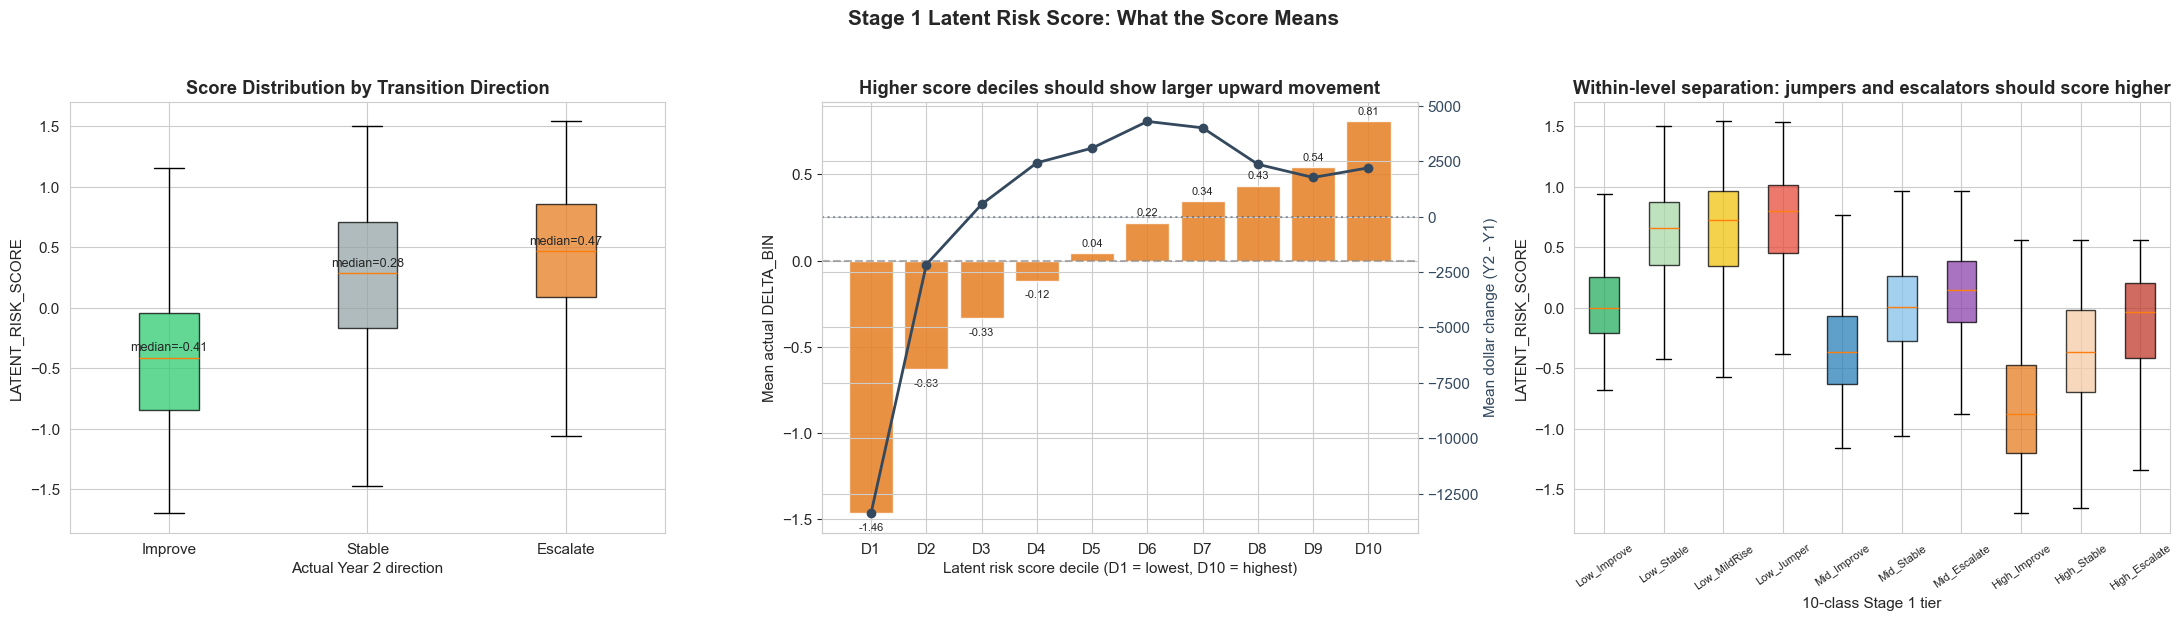

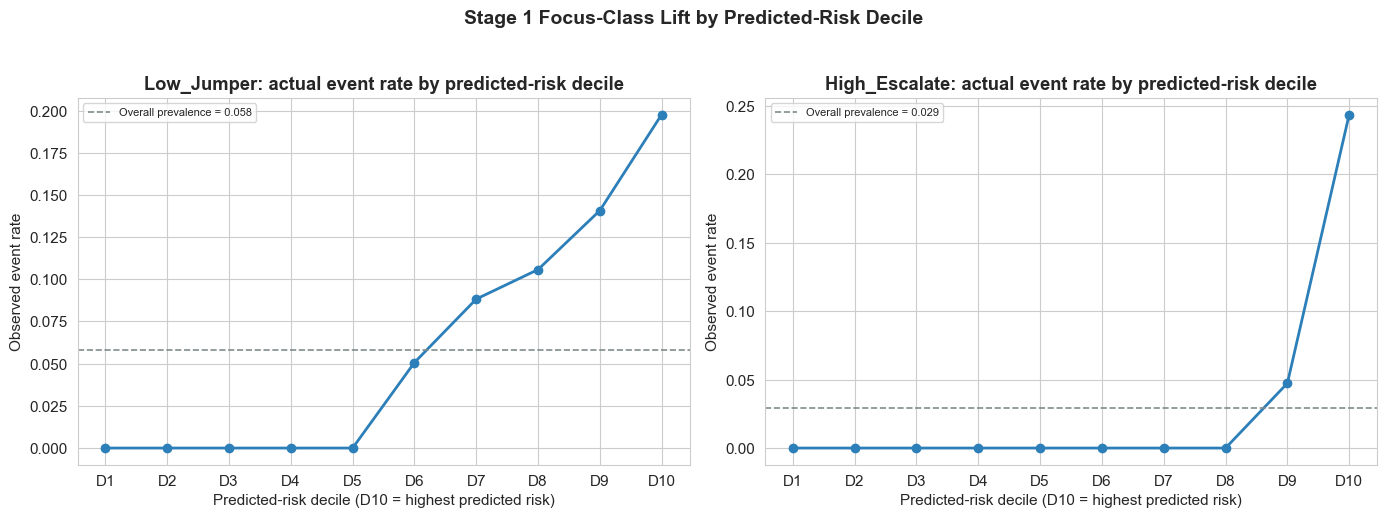


=== Stage 1 Latent Validation Summary ===


,_score_decile,mean_delta,mean_cost_y1,mean_cost_y2,n,mean_dollar_change
0,D1,-1.463455,22930.432292,9555.266443,6061,-13375.165849
1,D2,-0.629043,14484.992134,12323.943713,6060,-2161.048421
2,D3,-0.333663,10788.293536,11345.091649,6060,556.798112
3,D4,-0.116337,6049.234550,8480.783525,6060,2431.548975
4,D5,0.044224,3175.478429,6270.057305,6060,3094.578876
5,D6,0.220792,3592.292335,7892.101210,6060,4299.808875
6,D7,0.344389,2393.660335,6403.646234,6060,4009.985899
7,D8,0.433993,860.454736,3224.265594,6060,2363.810858
8,D9,0.541419,294.304257,2063.070838,6060,1768.766581
9,D10,0.807293,171.661901,2375.931572,6061,2204.269672


Spearman(decile, mean DELTA_BIN): 1.000
Spearman(decile, mean dollar change): 0.442

Focus-class lift summary:


,Class,BaseRate,TopDecileRate,TopDecileLift
0,Low_Jumper,0.058315,0.197657,3.389479
1,High_Escalate,0.029124,0.243854,8.372832


Recall Low_Jumper      : hard=0.140, policy_eval=0.140
Recall High_Escalate   : hard=0.493, policy_eval=0.493
Review rate: 0.000
Uncertainty score (mean): 0.458


In [13]:

# Latent score validation: readable plots for routing and healthcare interpretation
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Stage 1 Latent Risk Score: What the Score Means', fontsize=15, fontweight='bold', y=1.03)

direction_palette = {'Improve': '#2ecc71', 'Stable': '#95a5a6', 'Escalate': '#e67e22'}
trans_colors = {
    0: '#27ae60', 1: '#a8d8a8', 2: '#f1c40f', 3: '#e74c3c',
    4: '#2980b9', 5: '#85c1e9', 6: '#8e44ad',
    7: '#e67e22', 8: '#f5cba7', 9: '#c0392b',
}

plot_df = df[['RISK_TIER', 'LATENT_RISK_SCORE', 'DELTA_BIN', 'COST_Y1_ADJ', 'COST_Y2_ADJ']].copy()
plot_df['Direction3'] = plot_df['RISK_TIER'].map(DIRECTION3_MAP)

# Panel 1: score by direction (readable summary of whether score tracks worsening)
ax1 = axes[0]
dir_order = ['Improve', 'Stable', 'Escalate']
dir_data = [plot_df.loc[plot_df['Direction3'] == d, 'LATENT_RISK_SCORE'] for d in dir_order]
bp1 = ax1.boxplot(dir_data, labels=dir_order, patch_artist=True, showfliers=False)
for patch, d in zip(bp1['boxes'], dir_order):
    patch.set_facecolor(direction_palette[d])
    patch.set_alpha(0.75)
ax1.set_title('Score Distribution by Transition Direction', fontweight='bold')
ax1.set_xlabel('Actual Year 2 direction')
ax1.set_ylabel('LATENT_RISK_SCORE')
medians = plot_df.groupby('Direction3')['LATENT_RISK_SCORE'].median().reindex(dir_order)
for x, val in enumerate(medians, start=1):
    ax1.text(x, val + 0.06, f'median={val:.2f}', ha='center', fontsize=9)

# Panel 2: decile monotonicity with both delta-bin movement and dollar change
ax2 = axes[1]
plot_df['_score_decile'] = pd.qcut(
    plot_df['LATENT_RISK_SCORE'].rank(method='first'),
    10,
    labels=[f'D{i}' for i in range(1, 11)]
)
decile_stats = plot_df.groupby('_score_decile').agg(
    mean_delta=('DELTA_BIN', 'mean'),
    mean_cost_y1=('COST_Y1_ADJ', 'mean'),
    mean_cost_y2=('COST_Y2_ADJ', 'mean'),
    n=('DELTA_BIN', 'size')
).reset_index()
decile_stats['mean_dollar_change'] = decile_stats['mean_cost_y2'] - decile_stats['mean_cost_y1']

ax2.bar(decile_stats['_score_decile'], decile_stats['mean_delta'], color='#e67e22', alpha=0.85)
ax2.axhline(0, color='gray', ls='--', alpha=0.6)
for x, v in enumerate(decile_stats['mean_delta']):
    ax2.text(x, v + (0.04 if v >= 0 else -0.10), f'{v:.2f}', ha='center', fontsize=8)
ax2.set_xlabel('Latent risk score decile (D1 = lowest, D10 = highest)')
ax2.set_ylabel('Mean actual DELTA_BIN')
ax2.set_title('Higher score deciles should show larger upward movement', fontweight='bold')

ax2b = ax2.twinx()
ax2b.plot(decile_stats['_score_decile'], decile_stats['mean_dollar_change'], color='#34495e', marker='o', lw=2)
ax2b.axhline(0, color='#34495e', ls=':', alpha=0.5)
ax2b.set_ylabel('Mean dollar change (Y2 - Y1)', color='#34495e')
ax2b.tick_params(axis='y', colors='#34495e')

# Panel 3: score separation by 10-class tier
ax3 = axes[2]
ordered_tiers = sorted(plot_df['RISK_TIER'].unique())
score_data = [plot_df.loc[plot_df['RISK_TIER'] == t, 'LATENT_RISK_SCORE'] for t in ordered_tiers]
bp3 = ax3.boxplot(
    score_data,
    labels=[CLASS_NAMES[t] for t in ordered_tiers],
    patch_artist=True,
    showfliers=False,
)
for patch, t in zip(bp3['boxes'], ordered_tiers):
    patch.set_facecolor(trans_colors.get(t, 'gray'))
    patch.set_alpha(0.75)
ax3.set_xlabel('10-class Stage 1 tier')
ax3.set_ylabel('LATENT_RISK_SCORE')
ax3.set_title('Within-level separation: jumpers and escalators should score higher', fontweight='bold')
ax3.tick_params(axis='x', rotation=35, labelsize=8)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'latent_risk_score_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Focus-class lift chart: easier to interpret than reliability curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stage 1 Focus-Class Lift by Predicted-Risk Decile', fontsize=14, fontweight='bold', y=1.03)
lift_summary_rows = []

for ax, cls in zip(axes, [3, 9]):
    label = CLASS_NAMES[cls]
    prob_col = f'PROB_{label.upper()}'
    tmp = df[[prob_col, 'RISK_TIER']].copy()
    tmp['is_event'] = (tmp['RISK_TIER'] == cls).astype(int)
    tmp['prob_decile'] = pd.qcut(
        tmp[prob_col].rank(method='first'),
        10,
        labels=[f'D{i}' for i in range(1, 11)]
    )
    dec = tmp.groupby('prob_decile').agg(
        observed_rate=('is_event', 'mean'),
        mean_pred=('is_event', 'size')
    ).reset_index()
    prevalence = tmp['is_event'].mean()
    top_decile_rate = dec.loc[dec['prob_decile'] == 'D10', 'observed_rate'].iloc[0]
    lift = top_decile_rate / max(prevalence, 1e-12)
    lift_summary_rows.append({
        'Class': label,
        'BaseRate': prevalence,
        'TopDecileRate': top_decile_rate,
        'TopDecileLift': lift,
    })

    ax.plot(dec['prob_decile'], dec['observed_rate'], marker='o', lw=2, color='#2c7fb8')
    ax.axhline(prevalence, color='#7f8c8d', ls='--', lw=1.2, label=f'Overall prevalence = {prevalence:.3f}')
    ax.set_title(f'{label}: actual event rate by predicted-risk decile', fontweight='bold')
    ax.set_xlabel('Predicted-risk decile (D10 = highest predicted risk)')
    ax.set_ylabel('Observed event rate')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'stage1_reliability_focus_classes.png', dpi=150, bbox_inches='tight')
plt.show()

rho_delta = spearmanr(decile_stats.index + 1, decile_stats['mean_delta']).statistic
rho_change = spearmanr(decile_stats.index + 1, decile_stats['mean_dollar_change']).statistic
lift_summary_df = pd.DataFrame(lift_summary_rows)

print("\n=== Stage 1 Latent Validation Summary ===")
display(decile_stats)
print(f"Spearman(decile, mean DELTA_BIN): {rho_delta:.3f}")
print(f"Spearman(decile, mean dollar change): {rho_change:.3f}")
print("\nFocus-class lift summary:")
display(lift_summary_df)

for cls in [3, 9]:
    y_true = (df['RISK_TIER'] == cls)
    rec_hard = ((df['pred_class_hard'] == cls) & y_true).sum() / max(y_true.sum(), 1)
    rec_eval = ((df['STAGE1_PRED_CLASS_TUNED'] == cls) & y_true).sum() / max(y_true.sum(), 1)
    print(f"Recall {CLASS_NAMES[cls]:16s}: hard={rec_hard:.3f}, policy_eval={rec_eval:.3f}")

print(f"Review rate: {df['review_flag'].mean():.3f}")
print(f"Uncertainty score (mean): {df['uncertainty_score'].mean():.3f}")


### Latent Score Interpretation

These plots should answer three very specific questions.

**1. Does the latent score represent worsening risk, not just high cost?**

- In the first panel, patients who truly escalate should sit higher on `LATENT_RISK_SCORE` than stable or improving patients.
- In the second panel, the mean observed `DELTA_BIN` should rise as score decile increases. That is the direct test that the score is ranking transition severity, not just reproducing Year 1 spending.

**2. Does the score track spending change in dollars?**

- The dark line in the second panel shows mean **dollar change (`Y2 - Y1`)** by score decile.
- This is more faithful to the modeling goal than plotting raw Year 2 cost, because the latent score is supposed to rank **worsening**, not merely expensive patients.

**3. Are the focus-class probabilities usable as screening signals?**

- The lift charts replace the earlier reliability curves because they are easier to explain.
- Each point shows the **actual event rate** inside one predicted-risk decile.
- If the line rises sharply toward `D10`, then the model is concentrating true `Low_Jumper` or `High_Escalate` cases into the highest-risk patients.
- That does **not** mean the probability is perfectly calibrated; it means the score is useful for ranking patients for manual review or downstream soft routing.

**Healthcare reading**

- `LATENT_RISK_SCORE` is not a final clinical decision rule.
- Its main value is as a leakage-safe Stage 2 routing signal and as an interpretable “expected worsening” axis that uses more than prior cost alone.


In [14]:
# Save updated dataset with latent features for Stage 2
output_path = OUTPUT_STAGE1_PATH
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(output_path, index=False)

print("=== Stage 1 Output Saved ===")
print(f"Path: {output_path}")
print(f"Rows: {len(df):,}")
print(f"Run version: {STAGE1_NOTEBOOK_VERSION}")

new_cols = [
    c for c in df.columns
    if c.startswith('PROB_')
    or c.startswith('P_')
    or c in [
        'LATENT_RISK_SCORE', 'LATENT_RISK_SCORE_MANUAL', 'EXPECTED_DELTA_SCORE',
        'PRED_ENTROPY', 'uncertainty_score',
        'pred_class_hard', 'pred_class_policy', 'review_flag',
        'STAGE1_PRED_CLASS', 'STAGE1_PRED_CLASS_TUNED',
    ]
]
print(f"New Columns ({len(new_cols)}): {new_cols}")

# Save benchmark results with version marker
results_to_save = results_df.copy()
results_to_save['RunVersion'] = STAGE1_NOTEBOOK_VERSION
results_to_save.to_csv(REPORT_DIR / 'tables' / 'stage1_model_benchmark.csv', index=False)
print(f"\nBenchmark saved to: {REPORT_DIR / 'tables' / 'stage1_model_benchmark.csv'}")

# Save baseline lock table for reproducibility control
baseline_locked = results_to_save.copy()
baseline_locked['SelectedPipeline'] = selected_pipeline
baseline_locked['SelectedModelName'] = selected_model_name
baseline_locked['MajorityBaselineAccuracy'] = majority_acc
baseline_locked.to_csv(REPORT_DIR / 'tables' / 'baseline_locked_metrics.csv', index=False)
print(f"Baseline lock saved to: {REPORT_DIR / 'tables' / 'baseline_locked_metrics.csv'}")

# Save feature importance
if importance is not None:
    feat_imp_df.sort_values('Importance', ascending=False).to_csv(
        REPORT_DIR / 'tables' / 'stage1_feature_importance.csv', index=False
    )
    print(f"Feature importance saved to: {REPORT_DIR / 'tables' / 'stage1_feature_importance.csv'}")

# Save run metadata for quick freshness checks
meta = {
    'version': STAGE1_NOTEBOOK_VERSION,
    'saved_at_utc': datetime.utcnow().isoformat(),
    'selected_pipeline': selected_pipeline,
    'selected_model_name': selected_model_name,
    'rows': int(len(df)),
    'n_columns': int(len(df.columns)),
    'cv_scheme_oof': cv_name if 'cv_name' in globals() else 'unknown',
    'has_policy_template': bool('SELECTED_POLICY_FOR_OOF' in globals()),
    'policy_template': SELECTED_POLICY_FOR_OOF if 'SELECTED_POLICY_FOR_OOF' in globals() else None,
}
meta_path = REPORT_DIR / 'tables' / 'stage1_run_metadata.json'
meta_path.write_text(json.dumps(meta, indent=2))
print(f"Run metadata saved to: {meta_path}")

=== Stage 1 Output Saved ===
Path: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/data/processed_v2/model_ready_stage1.parquet
Rows: 60,602
Run version: stage1_decisionlayer_v2026_03_17_r1
New Columns (30): ['PROB_LOW_IMPROVE', 'P_LOW_IMPROVE', 'PROB_LOW_STABLE', 'P_LOW_STABLE', 'PROB_LOW_MILDRISE', 'P_LOW_MILDRISE', 'PROB_LOW_JUMPER', 'P_LOW_JUMPER', 'PROB_MID_IMPROVE', 'P_MID_IMPROVE', 'PROB_MID_STABLE', 'P_MID_STABLE', 'PROB_MID_ESCALATE', 'P_MID_ESCALATE', 'PROB_HIGH_IMPROVE', 'P_HIGH_IMPROVE', 'PROB_HIGH_STABLE', 'P_HIGH_STABLE', 'PROB_HIGH_ESCALATE', 'P_HIGH_ESCALATE', 'LATENT_RISK_SCORE_MANUAL', 'EXPECTED_DELTA_SCORE', 'LATENT_RISK_SCORE', 'PRED_ENTROPY', 'uncertainty_score', 'pred_class_hard', 'pred_class_policy', 'review_flag', 'STAGE1_PRED_CLASS', 'STAGE1_PRED_CLASS_TUNED']

Benchmark saved to: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/reports/tables/stage1_model_benchmark.csv
Baseline lock saved to: /Users/duanduan/Documents/NEU/ALY6980/healthcare_repo/rep

---
## Summary

**Stage 1 now serves two distinct purposes**

1. **Default routing model:** the selected hierarchical classifier remains the default Stage 1 model because it preserves the best overall 10-class structure for Stage 2.
2. **Screening sensitivity analysis:** one calibrated global policy is retained only to show what happens when we push harder for rare escalation recall.

**What we intentionally removed from the narrative**

- We no longer present a long list of near-duplicate policy experiments.
- We do not treat extremely low rare-class recall as an operational recommendation.
- We do not rely on threshold tuning as evidence of new signal; the stronger evidence is the gap between the cost-only model and the full model, plus the non-cost features that remain important after baseline cost is included.

**Stage 1 outputs passed to Stage 2**

- `PROB_*` / `P_*`: leakage-safe out-of-fold class probabilities
- `LATENT_RISK_SCORE`, `EXPECTED_DELTA_SCORE`
- `pred_class_hard`
- `pred_class_policy`, `review_flag` for sensitivity analysis only
- `uncertainty_score`

**Main storytelling takeaway**

Stage 1 confirms that Year 1 cost is powerful, but it is not the whole story. Utilization mix, medication burden, chronic burden, and engineered transition signals contribute additional information that supports Stage 2 expenditure prediction.
